# Laboratorium 07 — Detekcja obiektów — obrazy mikroskopowe krwi (BCCD)

W tym ćwiczeniu zajmiemy się problemem **detekcji obiektów** na obrazach medycznych. Zaimplementujemy od podstaw własną architekturę sieci, która w uproszczony sposób naśladuje działanie modeli typu Faster R-CNN.

**Cele zajęć:**
- Implementacja własnego datasetu dla zadania object detection z augmentacjami.
- Zrozumienie architektury sieci detekcyjnej: **backbone**, **RPN** (Region Proposal Network), **detection head**.
- Poznanie koncepcji **anchor boxes** i ich generowania.
- Implementacja funkcji straty dla detekcji: klasyfikacja obiekt/tło + regresja bounding boxów.
- Trening i ewaluacja modelu z wykorzystaniem metryki **mAP** (mean Average Precision).

**Dataset:**  
**BCCD (Blood Cell Count and Detection)** — zbiór obrazów mikroskopowych krwi z adnotacjami 3 klas komórek: białe krwinki (WBC), czerwone krwinki (RBC) i płytki krwi (Platelets). Zbiór zawiera 364 obrazy z adnotacjami. W notebooku wykorzystujemy bibliotekę **Albumentations** do augmentacji zachowujących spójność pomiędzy obrazem a bounding boxami.

## 0. Środowisko i instalacja pakietów

Przed rozpoczęciem pracy upewnij się, że masz zainstalowane wymagane biblioteki. Jeśli którejś brakuje, odkomentuj i uruchom poniższą komórkę.

In [1]:
# Jeśli brakuje pakietów, odkomentuj i uruchom:
%pip install -U pip
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip install pytorch-lightning torchmetrics[detection]
%pip install albumentations opencv-python matplotlib lxml rich

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 9.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 13.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pytorch-lightning]


## 1. Importy i ustawienia

Importujemy niezbędne biblioteki oraz konfigurujemy urządzenie obliczeniowe i precyzję operacji.

In [2]:
import os, random, json
from pathlib import Path
import xml.etree.ElementTree as ET

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image

import pytorch_lightning as pl
from pytorch_lightning import seed_everything

import albumentations as A
import cv2
import numpy as np
import matplotlib.pyplot as plt
from rich import print

from collections import Counter

from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image
from torchvision.models import ResNet18_Weights
import matplotlib.pyplot as plt
import torch

import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

import torchmetrics
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import box_iou, nms, roi_align

# seed_everything(42, workers=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Configure TF32 precision
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision('medium')  # 'medium' or 'high' for speed, 'highest' for accuracy


Using device: cuda

/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


## 2. Pobranie danych

Dane zostaną automatycznie pobrane przez sklonowanie repozytorium GitHub.

In [3]:
root = Path("data/data_bccd")
if not root.exists():
    root.mkdir(parents=True, exist_ok=True)
    exit_code = os.system(f"git clone --depth 1 https://github.com/Shenggan/BCCD_Dataset.git {root}")
    if exit_code != 0:
        print("Uwaga: nie udało się wykonać `git clone`.")
        print("https://github.com/Shenggan/BCCD_Dataset")

ann_dir = root / "BCCD/Annotations"
img_dir = root / "BCCD/JPEGImages"
set_dir = root / "BCCD/ImageSets/Main"

assert ann_dir.exists() and img_dir.exists() and set_dir.exists(), "Brakuje katalogów Annotations/JPEGImages/ImageSets."

xmls = sorted(list((ann_dir).glob("*.xml")))
imgs = sorted(list((img_dir).glob("*.jpg")))
print(f"Liczba adnotacji: {len(xmls)}, liczba obrazów: {len(imgs)}")

Liczba adnotacji: 364, liczba obrazów: 364

## 3. Parser VOC XML i mapowanie etykiet

Format Pascal VOC przechowuje adnotacje obiektów w plikach XML (ścieżka `ann_dir`) i podział na zbiory treningowy, testowy i walidacyjny (ścieżka `set_dir`). Każdy plik XML zawiera informacje o obrazie (rozmiar) oraz listę obiektów z ich współrzędnymi bounding boxów i etykietami klas. Poniżej jest zaimplementowana funkcja która wczytuje dane odnośnie prostokątów otaczających z podanego pliku XML.

W tej sekcji:
- Zdefiniowane są nazwy klas i tworzone mapowania między nazwami a indeksami (indeksy 1-3 dla klas, 0 jest zarezerwowane dla tła).
- Implementowano parser XML, który wydobywa współrzędne prostokątów i etykiety.

In [4]:
CLASS_NAMES = ["WBC", "RBC", "Platelets"]
NAME_TO_IDX = {name: i+1 for i, name in enumerate(CLASS_NAMES)}
IDX_TO_NAME = {i+1: name for i, name in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES) + 1  # + background

def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find("size")
    W = int(size.find("width").text)
    H = int(size.find("height").text)
    boxes, labels = [], []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        name = name.replace("Platelet", "Platelets")
        bnd = obj.find("bndbox")
        xmin = float(bnd.find("xmin").text)
        ymin = float(bnd.find("ymin").text)
        xmax = float(bnd.find("xmax").text)
        ymax = float(bnd.find("ymax").text)
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(NAME_TO_IDX.get(name, 0))
    return np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int64), (H, W)

## Zadanie 1 – Dataset, augmentacje i DataModule

W tym zadaniu zaimplementujemy klasy do wczytywania danych dla zadania detekcji z datasetu BCCD.

**Kluczowe różnice w porównaniu do klasyfikacji i segmentacji:**
- Dane wyjściowe to nie pojedyncza etykieta ani maska, ale **lista bounding boxów** i **lista etykiet** dla każdego obrazu.
- Augmentacje muszą transformować zarówno obraz jak i współrzędne bounding boxów (np. przy flip'ie musimy też przesunąć współrzędne).
- Używamy biblioteki **Albumentations**, która obsługuje augmentacje dla prostokątów otaczających.

**Dataset (BCCDDataset):**
1. Zaimplementuj klasę `BCCDDataset`, która dziedziczy po `Dataset`.
2. Metoda `__init__`:
   - Pryjmuje i zapamiętuje ścieżki do katalogów z obrazami (`img_dir`) i adnotacjami (`ann_dir`).
   - Kolejnym argumentem jest lista identyfikatorów obrazów (`indices`) — nazwy plików w danym zbiorze.
   - Ostatnim jest obiekt transformacji (`transforms`).
3. W metodzie `__len__` zwróć liczbę próbek.
4. W metodzie `__getitem__`:
   - Argumentem jest indeks pobieranej próbki.
   - Pobierz identyfikator obrazu z listy identyfikatorów na podstawie indeksu.
   - Skonstruuj ścieżki do pliku obrazu (`.jpg`) i adnotacji (`.xml`). Do ścieżek dodaj identyfikator i rozszerzenie.
   - Wczytaj obraz za pomocą `cv2.imread` i przekonwertuj z BGR na RGB.
   - Wczytaj plik z etykietami za pomocą funkcji `parse_voc_xml`.
   - Upewnij się, że wszystkie prostokąty mają poprawne współrzędne (`x2 > x1` i `y2 > y1`). Jeśli nie, odfiltruj niepoprawne boxy.
   - Jeśli `self.transforms` istnieje, zastosuj transformacje przekazując obraz, listę prostokątów oraz listę etykiet. Konwersję do listy wykonaj za pomocą metody `.tolist()`. Albumentations zwraca słownik z kluczami `"image"`, `"bboxes"`, `"class_labels"`.
   - Skonwertuj wynikowe prostokąty i etykiety z powrotem na `np.array`.
   - Przygotuj słownik `target` z kluczami:
     - `"boxes"` — tensor typu `float32` z bounding boxami.
     - `"labels"` — tensor typu `int64` z etykietami klas.
     - W formacie COCO są jeszcze dodatkowe pola (`"image_id"`, `"area"`, `"iscrowd"`), ale nie są one w naszej implementacji potrzebne.
   - Zwróć obrazy i docelowe prostokąty.

**Funkcja collate:**
1. Funkcja ta mówi w jaki sposób wczytane dane mają być łączone w batch. Dla zadania detekcji w kolejnych próbkach liczba prostokątów może być różna, więc łatwiej może być te dane połączyć w listę, zamiast tensor.
2. Zaimplementuj funkcję `collate_fn(batch)`:
   - Rozpakuj obrazy i targety: `imgs, targets = list(zip(*batch))` do dwóch osobnych list.
   - Zwróć te listy.

**DataModule (BCCDDataModule):**
1. Zaimplementuj klasę `BCCDDataModule`, która dziedziczy po `pl.LightningDataModule`.
2. Argumentami metody `__init__` są ścieżki do katalogów z obrazami, adnotacjami i podziałem zbiorów, rozmiar batcha i liczba workerów:
   - Zapamiętaj przekazane argumenty.
   - Zdefiniuj transformacje treningowe za pomocą `A.Compose`:
     - `A.RandomBrightnessContrast` — losowa zmiana jasności i kontrastu, jako argument przekaż prawdopodobieństwo,
     - `A.HorizontalFlip()` — losowe odbicie poziome, jako argument przekaż prawdopodobieństwo,
     - `A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))` — gdy nie używamy pretrenowanych wag do ResNet, `A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))` gdy używamy,
     - `A.ToTensorV2()` — konwersja do tensora PyTorch,
     - Przekaż `bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"])` jako argument dla funkcji `A.Compose`, aby Albumentations wiedziało jak modyfikować prostokąty.
   - Zdefiniuj transformacje walidacyjne analogicznie, ale bez augmentacji (tylko `A.NoOp()`, normalizacja i konwersja do tensora).
3. Zaimplementuj metodę pomocniczą, która przyjmuje plik podziału na zbiory jako argument:
   - Zwróć listę identyfikatorów (każda linia to jedna nazwa pliku):
   `with open(split_path, 'r') as f: ids = [line.strip() for line in f if line.strip()]`
4. W metodzie `setup(self, stage=None)`:
   - Wczytaj identyfikatory dla train, val i test używając zaimplementowanej metody pomocniczej.
   - Stwórz trzy datasety za pomocą zaimplementowanej wcześniej klasy, przekazując odpowiednie katalogi, identyfikatory i transformacje.
   - Wyświetl rozmiary zbiorów.
5. Zaimplementuj metody `train_dataloader()`, `val_dataloader()`, `test_dataloader()`:
   - Zwróć `DataLoader` z odpowiednim datasetem.
   - Ustaw `shuffle` tylko dla train.
   - Przekaż rozmiar batcha i liczbę workerów.
   - Ustaw `collate_fn=collate_fn`.

**Poza klasami:**
1. Stwórz instancję `BCCDDataModule` z odpowiednimi ścieżkami i parametrami.
2. Wywołaj `setup()`.
3. Pobierz dataloadery z zaimplementowanej ze stworzonej instancji.

In [5]:
class BCCDDataset(Dataset):
    def __init__(self, img_dir, ann_dir, indices, transforms=None):
        self.img_dir = Path(img_dir)
        self.ann_dir = Path(ann_dir)
        self.indices = indices
        self.transforms = transforms

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Pobierz identyfikator obrazu
        img_id = self.indices[idx]

        # Skonstruuj ścieżki do plików
        img_path = self.img_dir / f"{img_id}.jpg"
        ann_path = self.ann_dir / f"{img_id}.xml"

        # Wczytaj obraz
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Wczytaj adnotacje
        boxes, labels, (H, W) = parse_voc_xml(ann_path)

        # Filtruj niepoprawne bounding boxy
        valid_boxes = []
        valid_labels = []
        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box
            if x2 > x1 and y2 > y1:
                valid_boxes.append(box)
                valid_labels.append(label)

        boxes = np.array(valid_boxes, dtype=np.float32)
        labels = np.array(valid_labels, dtype=np.int64)

        # Zastosuj transformacje
        if self.transforms:
            transformed = self.transforms(
                image=image,
                bboxes=boxes.tolist(),
                class_labels=labels.tolist()
            )
            image = transformed["image"]
            boxes = np.array(transformed["bboxes"], dtype=np.float32) if transformed["bboxes"] else np.empty((0, 4), dtype=np.float32)
            labels = np.array(transformed["class_labels"], dtype=np.int64) if transformed["class_labels"] else np.empty((0,), dtype=np.int64)

        # Przygotuj target
        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        return image, target

def collate_fn(batch):
    imgs, targets = list(zip(*batch))
    return list(imgs), list(targets)

class BCCDDataModule(pl.LightningDataModule):
    def __init__(self, img_dir, ann_dir, set_dir, batch_size=4, num_workers=2):
        super().__init__()
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.set_dir = set_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

        # Transformacje dla zbioru treningowego
        self.train_transforms = A.Compose([
            A.RandomBrightnessContrast(p=0.3),
            A.HorizontalFlip(p=0.5),
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            A.ToTensorV2(),
        ], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"]))

        # Transformacje dla zbioru walidacyjnego/testowego
        self.val_transforms = A.Compose([
            A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
            A.ToTensorV2(),
        ], bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"]))

    def _load_split_ids(self, split_file):
        split_path = self.set_dir / split_file
        with open(split_path, 'r') as f:
            ids = [line.strip() for line in f if line.strip()]
        return ids

    def setup(self, stage=None):
        # Wczytaj identyfikatory dla każdego zbioru
        self.train_ids = self._load_split_ids("train.txt")
        self.val_ids = self._load_split_ids("val.txt")
        self.test_ids = self._load_split_ids("test.txt")

        # Utwórz datasets
        self.train_dataset = BCCDDataset(
            self.img_dir, self.ann_dir, self.train_ids, self.train_transforms
        )
        self.val_dataset = BCCDDataset(
            self.img_dir, self.ann_dir, self.val_ids, self.val_transforms
        )
        self.test_dataset = BCCDDataset(
            self.img_dir, self.ann_dir, self.test_ids, self.val_transforms
        )

        print(f"Train size: {len(self.train_dataset)}")
        print(f"Val size: {len(self.val_dataset)}")
        print(f"Test size: {len(self.test_dataset)}")

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            collate_fn=collate_fn
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=collate_fn
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            collate_fn=collate_fn
        )

# Testowanie implementacji
datamodule = BCCDDataModule(
    img_dir=img_dir,
    ann_dir=ann_dir,
    set_dir=set_dir,
    batch_size=4,
    num_workers=2
)

datamodule.setup()

# Pobierz dataloadery
train_loader = datamodule.train_dataloader()
val_loader = datamodule.val_dataloader()
test_loader = datamodule.test_dataloader()

# Przetestuj jeden batch
batch_imgs, batch_targets = next(iter(train_loader))
print(f"Batch images: {len(batch_imgs)}")
print(f"Batch targets: {len(batch_targets)}")
print(f"First image shape: {batch_imgs[0].shape}")
print(f"First target keys: {batch_targets[0].keys()}")
print(f"First target boxes shape: {batch_targets[0]['boxes'].shape}")
print(f"First target labels shape: {batch_targets[0]['labels'].shape}")

/usr/local/lib/python3.12/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


Train size: 205

Val size: 87

Test size: 72

Batch images: 4

Batch targets: 4

First image shape: torch.Size([3, 480, 640])

First target keys: dict_keys(['boxes', 'labels'])

First target boxes shape: torch.Size([15, 4])

First target labels shape: torch.Size([15])

## Zadanie 2 – Wizualizacja próbek z bounding boxami

Wyświetl kilka próbek ze zbioru treningowego razem z zaznaczonymi prostokątami otaczającymi.

1. Pobierz batch za pomocą `imgs, tgts = next(iter(dloader))`.
2. W pętli pobierz prostokąty i etykiety dla kolejnych próbek: `tgts[i]["boxes"]` i `tgts[i]["labels"]`.
3. Skonwertuj etykietę do nazwy za pomocą słownika `IDX_TO_NAME`: `labels_txt = [f"{IDX_TO_NAME.get(l.item(),'BG')}" for l in labels]`
4. Wygeneruj obraz z zaznaczonymi obiektami za pomocą funkcji `draw_bounding_boxes`. Przekaż jej obraz wejściowy, prostokąty i etykiety.
5. Wyświetl wynikowy obraz.

Training samples:

/usr/local/lib/python3.12/dist-packages/torchvision/utils.py:375: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


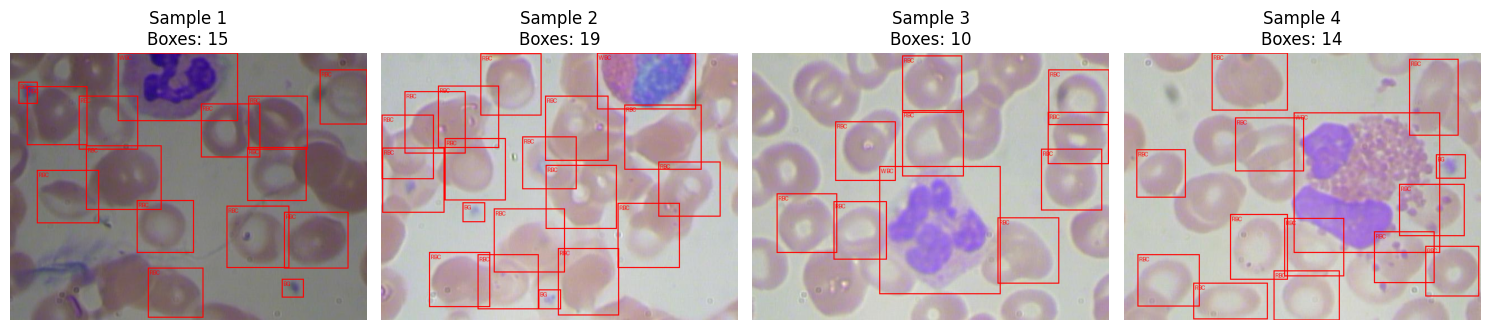

Validation samples:

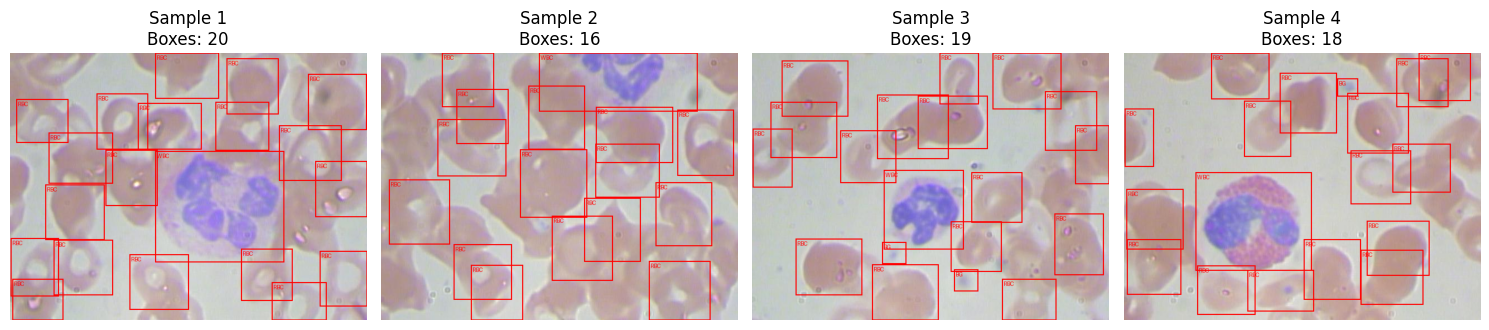

In [6]:
def visualize_samples(dloader, num_samples=4):
    """Wizualizacja próbek z bounding boxami"""
    # Pobierz batch danych
    imgs, tgts = next(iter(dloader))

    # Ogranicz do żądanej liczby próbek
    num_samples = min(num_samples, len(imgs))

    # Utwórz subplot
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]

    for i in range(num_samples):
        # Pobierz obraz i targety
        img = imgs[i]
        boxes = tgts[i]["boxes"]
        labels = tgts[i]["labels"]

        # Denormalizacja obrazu (przywrócenie do zakresu 0-255)
        img_denorm = (img * 0.5 + 0.5).clamp(0, 1)  # z [-1,1] do [0,1]

        # Konwersja etykiet na nazwy
        labels_txt = [f"{IDX_TO_NAME.get(l.item(), 'BG')}" for l in labels]

        # Rysowanie bounding boxów
        if len(boxes) > 0:
            # Konwersja do uint8 dla draw_bounding_boxes
            img_uint8 = (img_denorm * 255).byte()
            img_with_boxes = draw_bounding_boxes(
                img_uint8,
                boxes,
                labels=labels_txt,
                colors="red",
                width=2,
                font_size=12
            )
        else:
            img_with_boxes = (img_denorm * 255).byte()

        # Konwersja do PIL i wyświetlenie
        img_pil = to_pil_image(img_with_boxes)

        axes[i].imshow(img_pil)
        axes[i].set_title(f"Sample {i+1}\nBoxes: {len(boxes)}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Wizualizacja próbek treningowych
print("Training samples:")
visualize_samples(train_loader, num_samples=4)

# Wizualizacja próbek walidacyjnych
print("Validation samples:")
visualize_samples(val_loader, num_samples=4)

## Implementacja architektury sieci do detekcji

W kolejnych zadaniach zaimplementujemy architekturę sieci składającą się z czterech głównych komponentów: **Anchor Generator**, **Region Proposal Network**, **Detection Head** i **Detector** łączącego wszystko razem.

### Zadanie 3 – Anchor Generator

Anchor boxes to predefiniowane bounding boxy o różnych rozmiarach i proporcjach, które służą jako punkt odniesienia dla sieci. Dla każdej pozycji na feature mapie generujemy zestaw anchorów o różnych rozmiarach i kształtach.

1. Zaimplementuj klasę `AnchorGenerator`, która dziedziczy po `nn.Module`:
   - Konstruktorze przyjmuje i zapamiętuje listę rozmiarów anchorów (`sizes`) i proporcji boków (`aspect_ratios`).
   - Oblicz liczbę anchorów przypadających na jeden element z macierzy cech jako iloczyn liczby rozmiarów i liczby proporcji.
2. Zaimplementuj metodę `generate_anchors(self, feature_size, image_size, device)`:
   - Przyjmuje rozmiar mapy cech `(H, W)` i rozmiar obrazu `(img_h, img_w)`.
   - Oblicz stride (na ile pikseli w obrazie wejściowym przypada jedno pole mapy cech): `stride_h = img_h / h`, `stride_w = img_w / w`.
   - Wygeneruj współrzędne centrów anchorów dla każdej pozycji mapy cech mnożąc wektor `torch.arange(0, h, device=device, dtype=torch.float32)` przez stride i dodając połowę rozmiaru.
   - Stwórz dwuwymiarowe mapy tych współrzędnych za pomocą `torch.meshgrid(shifts_y, shifts_x, indexing='ij')`, a następnie spłaszcz je za pomocą metody `.reshape(-1)`.
   - Stwórz pustą listę na anchory.
   - Dla każdej kombinacji rozmiaru i proporcji (w pętli):
     - Oblicz wysokość i szerokość anchorów: `h_anchor = size / sqrt(aspect_ratio)`, `w_anchor = size * sqrt(aspect_ratio)`.
     - Dla każdego centrum oblicz współrzędne `(x1, y1, x2, y2)` anchora.
     - Połącz te współrzędne za pomocą `torch.stack` wzdłów wymiaru `dim=1`.
     - Dodaj macierz współrzędnych do listy anchorów (metoda `.append`).
   - Połącz wszystkie anchory w jeden tensor za pomocą metody `.cat` wzdłuż wymiaru `dim=0`.
   - Przytnij anchory do granic obrazu używając `torch.clamp`.
   - Zwróć tensor anchorów. Jego kształt to `[num_anchors*H*W, 4]`.

In [7]:
class AnchorGenerator(nn.Module):
    def __init__(self, sizes=[32, 64, 128], aspect_ratios=[0.5, 1.0, 2.0]):
        super().__init__()
        self.sizes = sizes
        self.aspect_ratios = aspect_ratios
        self.num_anchors_per_location = len(sizes) * len(aspect_ratios)
        self.num_anchors = self.num_anchors_per_location  # Dodajemy ten atrybut

    def generate_anchors(self, feature_size, image_size, device='cpu'):
        """
        Generuje anchory dla danej mapy cech.

        Args:
            feature_size: (H, W) - rozmiar mapy cech
            image_size: (img_h, img_w) - rozmiar obrazu wejściowego
            device: urządzenie do tworzenia tensorów

        Returns:
            anchors: tensor kształtu [H * W * num_anchors, 4]
                    w formacie (x1, y1, x2, y2)
        """
        h, w = feature_size
        img_h, img_w = image_size

        # Oblicz stride (krok siatki)
        stride_h = img_h / h
        stride_w = img_w / w

        # Generuj współrzędne centrów anchorów
        shifts_y = (torch.arange(0, h, device=device, dtype=torch.float32) + 0.5) * stride_h
        shifts_x = (torch.arange(0, w, device=device, dtype=torch.float32) + 0.5) * stride_w

        # Tworzenie siatki centrów
        shift_y, shift_x = torch.meshgrid(shifts_y, shifts_x, indexing='ij')
        shift_x = shift_x.reshape(-1)
        shift_y = shift_y.reshape(-1)

        anchors = []

        # Generuj anchory dla każdej kombinacji rozmiaru i proporcji
        for size in self.sizes:
            for aspect_ratio in self.aspect_ratios:
                # Oblicz wysokość i szerokość anchorów
                h_anchor = size / torch.sqrt(torch.tensor(aspect_ratio, device=device))
                w_anchor = size * torch.sqrt(torch.tensor(aspect_ratio, device=device))

                # Oblicz współrzędne bounding boxów względem centrów
                x1 = shift_x - w_anchor / 2
                y1 = shift_y - h_anchor / 2
                x2 = shift_x + w_anchor / 2
                y2 = shift_y + h_anchor / 2

                # Połącz współrzędne w tensor [N, 4]
                anchor_boxes = torch.stack([x1, y1, x2, y2], dim=1)
                anchors.append(anchor_boxes)

        # Połącz wszystkie anchory w jeden tensor
        anchors = torch.cat(anchors, dim=0)

        # Przytnij anchory do granic obrazu
        anchors[:, 0] = torch.clamp(anchors[:, 0], min=0, max=img_w)
        anchors[:, 1] = torch.clamp(anchors[:, 1], min=0, max=img_h)
        anchors[:, 2] = torch.clamp(anchors[:, 2], min=0, max=img_w)
        anchors[:, 3] = torch.clamp(anchors[:, 3], min=0, max=img_h)

        return anchors

# Testowanie AnchorGenerator
def test_anchor_generator():
    anchor_gen = AnchorGenerator(sizes=[32, 64], aspect_ratios=[0.5, 1.0, 2.0])

    # Przykładowe rozmiary
    feature_size = (4, 4)  # mała mapa cech
    image_size = (256, 256)  # rozmiar obrazu

    anchors = anchor_gen.generate_anchors(feature_size, image_size)

    print(f"Liczba anchorów: {anchors.shape[0]}")
    print(f"Kształt anchorów: {anchors.shape}")
    print(f"Liczba anchorów na lokalizację: {anchor_gen.num_anchors_per_location}")
    print(f"Liczba anchorów (atrybut): {anchor_gen.num_anchors}")
    print(f"Przykładowe anchory:\n{anchors[:6]}")

    # Sprawdź poprawność wymiarów
    expected_num_anchors = feature_size[0] * feature_size[1] * anchor_gen.num_anchors_per_location
    print(f"Oczekiwana liczba anchorów: {expected_num_anchors}")
    print(f"Rzeczywista liczba anchorów: {anchors.shape[0]}")

    # Sprawdź czy anchory mieszczą się w obrazie
    assert torch.all(anchors[:, 0] >= 0) and torch.all(anchors[:, 0] <= image_size[1]), "Anchory poza obrazem w osi X (min)"
    assert torch.all(anchors[:, 1] >= 0) and torch.all(anchors[:, 1] <= image_size[0]), "Anchory poza obrazem w osi Y (min)"
    assert torch.all(anchors[:, 2] >= 0) and torch.all(anchors[:, 2] <= image_size[1]), "Anchory poza obrazem w osi X (max)"
    assert torch.all(anchors[:, 3] >= 0) and torch.all(anchors[:, 3] <= image_size[0]), "Anchory poza obrazem w osi Y (max)"

    print("Test AnchorGenerator: PASSED")
    return anchors

# Uruchom test
test_anchors = test_anchor_generator()

Liczba anchorów: 96

Kształt anchorów: torch.Size([96, 4])

Liczba anchorów na lokalizację: 6

Liczba anchorów (atrybut): 6

Przykładowe anchory:
tensor([[ 20.6863,   9.3726,  43.3137,  54.6274],
        [ 84.6863,   9.3726, 107.3137,  54.6274],
        [148.6863,   9.3726, 171.3137,  54.6274],
        [212.6863,   9.3726, 235.3137,  54.6274],
        [ 20.6863,  73.3726,  43.3137, 118.6274],
        [ 84.6863,  73.3726, 107.3137, 118.6274]])

Oczekiwana liczba anchorów: 96

Rzeczywista liczba anchorów: 96

Test AnchorGenerator: PASSED

### Zadanie 4 - Region Proposal Network

RPN to sieć, która dla każdego anchora przewiduje czy zawiera obiekt (objectness) i korekty współrzędnych anchorów (bbox deltas).

1. Zaimplementuj klasę `RPN`, która dziedziczy po `nn.Module`:
   - Konstruktor przyjmuje liczbę warstw (cech) i liczbę anchorów:
     - Stwórz warstwę konwolucyjną (3x3, padding=1) przetwarzającą cechy. Wejście i wyjście ma tę samą liczbę kanałów.
     - Stwórz warstwę konwolucyjną (1x1) przewidującą prawdopodobieństwo obiektu dla każdego anchora. Na wyjściu liczba kanałów jest równa liczbie anchorów.
     - Stwórz warstwę konwolucyjną (1x1) przewidującą 4 delty dla każdego anchora. Na wyjściu liczba kanałów jest równa liczbie anchorów pomnożonej przez 4.
2. W metodzie `forward(self, features)`:
   - Przepuść cechy przez pierwszą warstwę konwolucyjną i aktywację ReLU (`F.relu`).
   - Wyjście pierwszej warstwy przepuść przez dwie pozostałe.
   - Przekształć objectness do odpowiedniego kształtu `.permute(0, 2, 3, 1).reshape(batch_size, -1)`.
   - Przekształć bbox_deltas do odpowiedniego kształtu `.permute(0, 2, 3, 1).reshape(batch_size, -1, 4)`.
   - Zwróć objectness i bbox_deltas.

In [8]:
class RPN(nn.Module):
    def __init__(self, in_channels=512, num_anchors=9):
        """
        Region Proposal Network

        Args:
            in_channels: liczba kanałów wejściowych z backbone
            num_anchors: liczba anchorów na każdą pozycję (sizes * aspect_ratios)
        """
        super().__init__()
        self.num_anchors = num_anchors

        # Główna warstwa konwolucyjna RPN
        self.conv = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, padding=1
        )

        # Warstwa klasyfikacji - przewiduje prawdopodobieństwo obiektu dla każdego anchora
        self.objectness_conv = nn.Conv2d(
            in_channels, num_anchors,
            kernel_size=1
        )

        # Warstwa regresji - przewiduje 4 delty dla każdego anchora
        self.bbox_deltas_conv = nn.Conv2d(
            in_channels, num_anchors * 4,
            kernel_size=1
        )

        # Inicjalizacja wag
        self._init_weights()

    def _init_weights(self):
        """Inicjalizacja wag warstw konwolucyjnych"""
        for module in [self.conv, self.objectness_conv, self.bbox_deltas_conv]:
            nn.init.normal_(module.weight, std=0.01)
            nn.init.constant_(module.bias, 0)

    def forward(self, features):
        """
        Forward pass RPN

        Args:
            features: tensor cech z backbone [batch_size, channels, H, W]

        Returns:
            objectness: tensor [batch_size, H * W * num_anchors]
            bbox_deltas: tensor [batch_size, H * W * num_anchors, 4]
        """
        batch_size = features.shape[0]

        # Główna konwolucja RPN z aktywacją ReLU
        x = F.relu(self.conv(features))

        # Przewidywanie objectness (logity dla obiekt/tło)
        objectness = self.objectness_conv(x)

        # Przewidywanie delt bounding boxów
        bbox_deltas = self.bbox_deltas_conv(x)

        # Zmiana kształtu objectness: [batch_size, num_anchors, H, W] -> [batch_size, H * W * num_anchors]
        objectness = objectness.permute(0, 2, 3, 1).contiguous().view(batch_size, -1)

        # Zmiana kształtu bbox_deltas: [batch_size, num_anchors*4, H, W] -> [batch_size, H * W * num_anchors, 4]
        bbox_deltas = bbox_deltas.permute(0, 2, 3, 1).contiguous().view(batch_size, -1, 4)

        return objectness, bbox_deltas

# Testowanie RPN
def test_rpn():
    # Parametry testowe
    batch_size = 2
    in_channels = 512
    feature_size = (16, 16)  # H, W mapy cech
    num_anchors = 9  # 3 sizes * 3 aspect ratios

    # Tworzenie RPN
    rpn = RPN(in_channels=in_channels, num_anchors=num_anchors)

    # Przykładowe cechy wejściowe
    features = torch.randn(batch_size, in_channels, feature_size[0], feature_size[1])

    # Forward pass
    objectness, bbox_deltas = rpn(features)

    print(f"Input features shape: {features.shape}")
    print(f"Objectness shape: {objectness.shape}")
    print(f"Bbox deltas shape: {bbox_deltas.shape}")

    # Sprawdzenie oczekiwanych kształtów
    expected_objectness_shape = (batch_size, feature_size[0] * feature_size[1] * num_anchors)
    expected_bbox_deltas_shape = (batch_size, feature_size[0] * feature_size[1] * num_anchors, 4)

    print(f"Expected objectness shape: {expected_objectness_shape}")
    print(f"Expected bbox_deltas shape: {expected_bbox_deltas_shape}")

    assert objectness.shape == expected_objectness_shape, f"Objectness shape mismatch: {objectness.shape} vs {expected_objectness_shape}"
    assert bbox_deltas.shape == expected_bbox_deltas_shape, f"Bbox deltas shape mismatch: {bbox_deltas.shape} vs {expected_bbox_deltas_shape}"

    print("Test RPN: PASSED")

    return rpn, objectness, bbox_deltas

# Uruchom test
rpn_model, test_objectness, test_bbox_deltas = test_rpn()

Input features shape: torch.Size([2, 512, 16, 16])

Objectness shape: torch.Size([2, 2304])

Bbox deltas shape: torch.Size([2, 2304, 4])

Expected objectness shape: (2, 2304)

Expected bbox_deltas shape: (2, 2304, 4)

Test RPN: PASSED

### Zadanie 5 - Detection Head

Head przyjmuje cechy z ROI i przewiduje finalną klasę obiektu oraz korekty prostokątów otaczających. Rozmiar batcha dla tek klasy jest równy liczbie prostokątów dla których wykonywana jest predykcja.

1. Zaimplementuj klasę `DetectionHead`, która dziedziczy po `nn.Module`:
   - Konstruktor przyjmuje liczbę kanałów (cech) i liczbę klas:
     - Stwórz dwie warstwy w pełni połączone. Liczba kanałów na wejściu pierwszej jest równa liczbie cech pomnożononej przez rozmiar przestrzenny tensora cech. Dla ResNet jako backbone jest to `in_channels * 7 * 7`. Dobierz pozostałe liczby kanałów.
     - Stwórz w pełni połączoną warstwę klasyfikacji. Liczba kanałów na wyjściu jest równa liczbie klas.
     - Stwórz w pełni połączoną warstwę regresji prostokątów. Liczba kanałów na wyjściu jest równa 4.
2. W metodzie `forward(self, roi_features)`:
   - Spłaszcz cechy ROI: `x = roi_features.flatten(start_dim=1)`.
   - Przepuść przez dwie pierwsze warstwy w pełni połączone.
   - Oblicz logity klas i korekty prostokątów za pomocą dwóch pozostałych warstw.
   - Zwróć logity i korekty prostokątów otaczających.

In [9]:
class DetectionHead(nn.Module):
    def __init__(self, in_channels=512, num_classes=4, hidden_size=1024):
        """
        Detection Head dla finalnej klasyfikacji i regresji bounding boxów

        Args:
            in_channels: liczba kanałów wejściowych z ROI Align
            num_classes: liczba klas (wliczając tło)
            hidden_size: rozmiar ukrytych warstw
        """
        super().__init__()
        self.num_classes = num_classes

        # Rozmiar po spłaszczeniu cech ROI (dla ROI Align 7x7)
        self.roi_feature_size = 7
        in_features = in_channels * self.roi_feature_size * self.roi_feature_size

        # Dwie warstwy w pełni połączone do ekstrakcji cech
        self.fc1 = nn.Linear(in_features, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)

        # Warstwa klasyfikacji - przewiduje logity dla każdej klasy
        self.cls_score = nn.Linear(hidden_size, num_classes)

        # Warstwa regresji - przewiduje 4 korekty dla każdej klasy
        self.bbox_pred = nn.Linear(hidden_size, num_classes * 4)

        # Inicjalizacja wag
        self._init_weights()

    def _init_weights(self):
        """Inicjalizacja wag warstw"""
        # Inicjalizacja warstw FC
        for module in [self.fc1, self.fc2]:
            nn.init.normal_(module.weight, std=0.01)
            nn.init.constant_(module.bias, 0)

        # Inicjalizacja warstw wyjściowych
        nn.init.normal_(self.cls_score.weight, std=0.01)
        nn.init.constant_(self.cls_score.bias, 0)

        nn.init.normal_(self.bbox_pred.weight, std=0.001)
        nn.init.constant_(self.bbox_pred.bias, 0)

    def forward(self, roi_features):
        """
        Forward pass Detection Head

        Args:
            roi_features: tensor cech ROI [num_rois, channels, 7, 7]

        Returns:
            cls_logits: tensor logitów klas [num_rois, num_classes]
            bbox_deltas: tensor delt bounding boxów [num_rois, num_classes * 4]
        """
        # Spłaszcz cechy ROI
        x = roi_features.flatten(start_dim=1)

        # Przejście przez warstwy FC z aktywacjami ReLU
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        # Przewidywanie logitów klas
        cls_logits = self.cls_score(x)

        # Przewidywanie delt bounding boxów
        bbox_deltas = self.bbox_pred(x)

        return cls_logits, bbox_deltas

# Testowanie DetectionHead
def test_detection_head():
    # Parametry testowe
    num_rois = 32  # liczba regionów zainteresowania
    in_channels = 512
    num_classes = 4  # 3 klasy + tło
    roi_size = 7

    # Tworzenie DetectionHead
    detection_head = DetectionHead(
        in_channels=in_channels,
        num_classes=num_classes,
        hidden_size=1024
    )

    # Przykładowe cechy ROI (wyjście z ROI Align)
    roi_features = torch.randn(num_rois, in_channels, roi_size, roi_size)

    # Forward pass
    cls_logits, bbox_deltas = detection_head(roi_features)

    print(f"Input ROI features shape: {roi_features.shape}")
    print(f"Class logits shape: {cls_logits.shape}")
    print(f"Bbox deltas shape: {bbox_deltas.shape}")

    # Sprawdzenie oczekiwanych kształtów
    expected_cls_shape = (num_rois, num_classes)
    expected_bbox_shape = (num_rois, num_classes * 4)

    print(f"Expected class logits shape: {expected_cls_shape}")
    print(f"Expected bbox deltas shape: {expected_bbox_shape}")

    assert cls_logits.shape == expected_cls_shape, f"Class logits shape mismatch: {cls_logits.shape} vs {expected_cls_shape}"
    assert bbox_deltas.shape == expected_bbox_shape, f"Bbox deltas shape mismatch: {bbox_deltas.shape} vs {expected_bbox_shape}"

    print("Test DetectionHead: PASSED")

    return detection_head, cls_logits, bbox_deltas

# Uruchom test
detection_head_model, test_cls_logits, test_bbox_deltas = test_detection_head()

Input ROI features shape: torch.Size([32, 512, 7, 7])

Class logits shape: torch.Size([32, 4])

Bbox deltas shape: torch.Size([32, 16])

Expected class logits shape: (32, 4)

Expected bbox deltas shape: (32, 16)

Test DetectionHead: PASSED

### Zadanie 6 - Detektor

To główna klasa łącząca backbone, anchor generator, RPN i detection head w kompletny model detekcji. Z uwagi na dużą ilość potrzebnego kodu, część potrzebnych funkcjonalności jest już zaimplementowana.

1. Zaimplementuj klasę `Detector`, która dziedziczy po `nn.Module`:
   - W konstruktorze (już zaimplementowany):
     - Załaduj backbone (ResNet18 bez ostatnich warstw FC): `self.backbone = nn.Sequential(*list(resnet.children())[:-2])`.
     - Stwórz instancję `AnchorGenerator` z odpowiednimi parametrami.
     - Stwórz instancję `RPN` z liczbą kanałów backbonu i liczbą anchorów.
     - Stwórz instancję `DetectionHead`.
     - Zdefiniuj hiperparametry treningu i inferencji (progi IoU, NMS, rozmiary batchy, itp.).

2. Zaimplementuj metody pomocnicze do kodowania/dekodowania bounding boxów:
   - `_xyxy_to_cxcywh(boxes)`:
     - rozłóż wejściowy wektor na składowe (`x1, y1, x2, y2 = boxes.unbind(-1)`),
     - oblicz szerokość i wysokość,
     - oblicz współrzędne środka,
     - połącz obliczone wielkości za pomocą `torch.stack` wzdłóż ostatniego wymiaru `dim=-1`,
     - zwróć stworzony wektor.
   - `_cxcywh_to_xyxy(boxes)`:
     - rozłóż wejściowy wektor na składowe (`cx, cy, w, h = boxes.unbind(-1)`),
     - oblicz współrzędne zewnętrzne prostokąta otaczającego,
     - połącz obliczone wielkości za pomocą `torch.stack` wzdłóż ostatniego wymiaru `dim=-1`,
     - zwróć stworzony wektor.
   - `encode_boxes(target_boxes, reference_boxes)`:
     - przekształca współrzędne wyznaczonych prostokątów na korekty względem prostokątów referencyjnych,
     - zamieneń współrzędne zewnętrzne do współrzędnych środka, szerokości i wysokości za pomocą wcześniejszej funkcji,
     - oblicz relatywne przesunięcie środków: $(xc_t - xc_r)/w_r$, $(yc_t - yc_r)/h_r$,
     - oblicz logarytmiczną skalę: $log(w_t / w_r)$, $log(h_t / h_r)$ (dodaj zabezpieczenie przed zbyt małą wartością argumentu `.clamp(min=1e-6)`),
     - połącz obliczone wielkości za pomocą `torch.stack` wzdłóż wymiaru `dim=1`,
     - zwróć stworzony wektor.
   - `decode_boxes(deltas, reference_boxes)`:
     - odwrotna operacja, przekształca delty (dx, dy, dw, dh) na współrzędne prostokątów,
     - zamień współrzędne zewnętrzne do współrzędnych środka, szerokości i wysokości,
     - oblicz współrzędne środka: $dx * w_r + xc_r$, $dy * h_r + yc_r$,
     - oblicz wysokość i szerokość: $w_r * exp(dw)$, $h_r * exp(dh)$
     - połącz obliczone wielkości za pomocą `torch.stack` wzdłóż ostatniego wymiaru`dim=-1`,
     - Skonwertuj stworzony wektor do współrzędnych zewnętrznych (zaimplementowana wcześniej funkcja),
     - zwróć stworzony wektor.
   - `clip_boxes_to_image(boxes, img_h, img_w)`:
     - przycina współrzędne do granic obrazu,
     - zastosuj metodę `.clamp`.

3. W metodzie `forward(self, images, targets=None)`:
   - Złóż obrazy w batch (`torch.stack`) i przepuść przez backbone aby uzyskać mapy cech.
   - Wygeneruj anchory dla danego rozmiaru mapy cech (metoda `generate_anchors`).
   - Przepuść cechy przez RPN aby uzyskać prawdopodobieństwa obiektów i korekty anchorów.
   - Jeśli `self.training` i przekazano `targets`:
     - Wywołaj metodę i zwróć wynik `self._compute_loss(objectness, bbox_deltas, anchors, features, targets, batch_size, img_h, img_w)` aby obliczyć straty.
   - W przeciwnym razie:
     - Wywołaj metodę i zwróć wynik `self._inference(objectness, bbox_deltas, anchors, features, batch_size, img_h, img_w)` aby wygenerować finalne predykcje.

4. Zaimplementuj pomocniczą metodę `_sample_regions(self, pos_mask, neg_mask, batch_size, pos_fraction)`:
   - Ma ona wyznaczyć losowe podzbiory z wyznaczonych prostokątów, jeśli jest ich zbyt dużo. `batch_size` jest maksymalną liczbą próbek. `pos_fraction` jest pozytywną częścią próbek.
   - Znajdź wszystkie indeksy pozytywnych próbek (`pos_mask`) używając `torch.nonzero(pos_mask, as_tuple=False).squeeze(1)`.
   - Wykonaj to samo dla negatywnych próbek.
   - Oblicz liczbę pozytywnych próbek do wylosowania: `num_pos = int(batch_size * pos_fraction)`.
   - Jeśli liczba dostępnych pozytywnych próbek jest większa niż `num_pos`, wylosuj `num_pos` indeksów używając `torch.randperm`. Jej pierwszym argumentem jest liczba próbek, a drugim urządzenie na którym wykonywane są obliczenia. Następnie wybieramy `num_pos` początkowych elementów wyniku. Na podstawie tych elementów  wybieramy później indeksy pozytywnych próbek.
   - W przeciwnym razie użyj wszystkich dostępnych pozytywnych próbek.
   - Oblicz maksymalną liczbę negatywnych próbek jako `batch_size` pomniejszone o liczbę wylosowanych pozytywnych próbek.
   - Jeśli liczba dostępnych negatywnych próbek jest większa niż maksymalna liczbę negatywnych próbek, wylosój indeksy podobnie jak wcześniej dla pozytywnych.
   - W przeciwnym razie użyj wszystkich dostępnych negatywnych próbek.
   - Zwróć cztery tensory: wylosowane pozytywne indeksy, wylosowane negatywne indeksy, wszystkie pozytywne indeksy, wszystkie negatywne indeksy.

5. Zaimplementuj metodę `_compute_loss(self, objectness, bbox_deltas, anchors, features, targets, batch_size, img_h, img_w)`:
   - Dla każdego obrazu w batchu:
     - **RPN loss:**
       - Oblicz IoU między anchorami a ground truth boxami. Użyj funkcji `box_iou`. Jej pierwszym argumentem są współrzędne anchorów `anchors`, a drugim prostokąty otaczające danej próbki `gt_boxes`.
       - Wyznacz maksymalne IoU dla każdego anchora `max_iou, matched_gt_idx = ious.max(dim=1)`.
       - Stwórz maskę pozytywnych anchorów (`max_iou` większe od `rpn_fg_iou_thresh`)
       - Stwórz maskę negatywnych anchorów (`max_iou` mniejsze od `rpn_bg_iou_thresh`)
       - Wyznacz próbki, które zostaną wykorzystane do funkcji straty dla objectness za pomocą metody `self._sample_regions`. Dwoma pierwszymi argumentami są wyznaczone maski. Kolejnymi są `rpn_batch_size` i `rpn_positive_fraction`.
       - Połącz indeksy wyosowanych pozytywnych i negatywnych próbek za pomocą `torch.cat` wzdłóż wymiaru `dim=0`.
       - Stwórz tensor docelowego objectness. Wykorzystaj `torch.zeros_like`, a jako argument podaj objectness wyznaczone z RPN dla danej próbki. Następnie wartości pod elementami z maski pozytywnych elementów zamień na `1.0`.
       - Wybierz wartości z objectness RPN i wyznaczonych targetów spod wylosowanych indeksów.
       - Oblicz stratę objectness za pomocą `F.binary_cross_entropy_with_logits`. Dodaj ją do listy `rpn_cls_losses`.
       - Następnie wyznacz docelowe korekty anchorów za pomocą metody `encode_boxes`. Pierwszym argumentem są prostokąty otaczające odpowiadające wszystkim anchorom oznaczonym jako pozytywne `gt_boxes[matched_gt_idx[all_pos_idx]]`, a drugim same pozytywne anchory `anchors[all_pos_idx]`.
       - Wyznacz korekty z wyjścia sieci dla pozytywnych anchorów `bbox_deltas[i][all_pos_idx]`.
       - Oblicz stratę dla korekt prostokątów za pomocą `F.smooth_l1_loss`. Przekaż dodatkowo parametr `reduction='mean'`.
       - Dodaj obliczoną stratę do listy `rpn_reg_losses`.
     - **Detection head loss:**
       - Wybierz propozycje ROI dla head (z wyłączonym obliczaniem gradientu) `with torch.no_grad():`
       - Oblicz skorygowane prostokąty na podstawie wyników z RPN za pomocą funkcji `self.decode_boxes`. Pierwszym argumentem są korekty dla danej próbki z RPN, a drugim współrzędne anchorów.
       - Przytnij współrzędne prostokątów do rozmiaru obrazu za pomocą metody `clip_boxes_to_image`.
       - Skonwertuj wyniki objectness do prawdopodobieństwa za pomocą `torch.sigmoid`.
       - Następnie chcemy pozbyć się nakładających się prostokątów, które nie są lokalnym maksimum prawdopodobieństwa. W tym celu wykorzystaj funkcję `nms`. Jej pierwszym argumentem są skorygowane prostokąty otaczające, drugim ich prawdopodobieństwa, a trzecim parametr `rpn_nms_thresh`. Wyjściem jest maska o takiej liczbie elementów jak wejściowe prostokąty.
       - Wybierz prostokąty i prawdopodobieństwa na podstawie wyniku NMS.
       - Jeśli liczba prostokątów jest większa niż `box_nms_num_keep`, to wybierz `box_nms_num_keep` o największym prawdopodobieństwie (jeśli nie, to chcemy je po prostu posortować). Wykorzystaj funkcję `torch.topk` i pobierz indeksy z wyniku za pomocą pola `.indices`. Pierwszym argumentem są prawdopodobieństwa po NMS, a drugim liczba prostokątów, które chcemy.
       Następnie posortuj prostokąty za pomocą otrzymanych indeksów.
       - Kolejne obliczenia są już wykonywane z obliczaniem gradientów (poza blokiem `box_nms_num_keep`).
       - Oblicz IoU posortowanych prostokątów względem docelowych prostokątów dla danej próbki za pomocą funkcji `box_iou`.
       - Następnie sprawdzamy maksymalne IoU dla każdego prostokąta (wzdłuż wymiaru `dim=1`).
       - Sprawdzamy pozytywne i negatywne prostokąty za pomocą parametrów `roi_fg_iou_thresh` i `roi_bg_iou_thresh` podobnie jak przed RPN.
       - Jeśli prostokątów pozytywnych lub negatywnych jest zbyt dużo to chcemy wylosować założoną liczbę, podobnie jak przed obliczaniem straty dla objectness dla RPN, za pomocą metody `_sample_regions`. W tym wypadku wykorzystaj parametry `roi_batch_size` i `roi_positive_fraction`.
       - Również połącz przefiltrowane indeksy pozytywne i negatywne w jeden tensor za pomocą `torch.cat` wzdłóż zerowego wymiaru.
       - Na podstawie stworzonego tensora z indeksami wybierz prostokąty, odpowiadające im indeksy prostokątów docelowych (drugi wynik wcześniej obliczanego maksimum IoU), a następnie etykiety docelowe dla danych prostokątów (tutaj dodatkowo chcemy je skopiować za pomocą metody `.clone()`).
       - Wybrane docelowe etykiety musimy dodatkowo zmodyfikować. Jeśli dany prostokąt został sklasyfikowany jako negatywny to docelową etykietę chcemy zmienić na 0. W tym celu warto sprawdzić ile było etykiet pozytywnych na wyjściu metody `_sample_regions`.
       - Do head musimy przekazać cechy odpowiadające wyznaczonym prostokątom. Chcemy je wyliczyć z przekazanej mapy cech za pomocą interpolacji biliniowej na podstawie współrzędnych prostokątów w obrazie wejściowym. W tym celu wykorzystujemy funkcję `roi_align`. Pierwszym argumentem jest mapa cech odpowiadająca przetwarzanej próbce `features[[i]]` (podwójny nawias zachowuje wymiar batcha), a drugim lista tensorów `[sel_props]` zawierająca wylosowane wcześniej prostokąty (dane są przekazywane jako lista, bo funkcja pozwala na obliczenia dla wielu próbek w batchu). Trzecim argumentem (`output_size`) jest rozmiar przestrzenny mapy cech, a czwartym (`spatial_scale`) skala obliczona na początku metody.
       - Oblicz wyjścia head dla przeskalowanych cech prostokątów, obliczając prawdopodobieństwa dla klas i dodatkowe korekcje prostokątów.
       - Teraz oblicz stratę klasyfikacji prostokątów za pomocą head `F.cross_entropy`. Przekaż jej wynik klasyfikacji i docelowe etykiety. Zastosuj również `label_smoothing=self.label_smoothing`. Dodaj obliczoną stratę do listy `roi_cls_losses`.
       - Następnie chcemy obliczyć stratę korekt prostokątów otaczających z head dla sklasyfikowanych wcześniej jako pozytywne.
       - Wybierz prostokąty oznaczone wcześniej jako pozytywne (np. na podstawie liczebności pozytywnych indeksów na wyjściu z losowania prostokątów).
       - Wybierz również odpowiadajce im współrzędne docelowe.
       - Skonwertuj wybrane prostokąty i współrzędne docelowe do korekt za pomocą metody `encode_boxes`.
       - Wybierz również wyjściowe korekty z head odpowiadające pozytywnym próbkom.
       - Oblicz stratę korekt z head za pomocą `F.smooth_l1_loss`. Przekaż wybrane korekty z head oraz odpowiadające docelowe korekty. Dodatkowo przekaż `reduction='mean'`.
       - Wynik dodaj do listy `roi_reg_losses`.
   - Na koniec (poza pętlą dla batcha) łączymy obliczone straty w jedną wartość (już zaimplementowane) i zwracamy słownik.

6. Zaimplementuj metodę `_inference(self, objectness, bbox_deltas, anchors, features, batch_size, img_h, img_w)`:
   - Dla każdego obrazu w batchu (w pętli):
     - Skonwertuj objectness do prawdopodobieństw `torch.sigmoid`.
     - Zamień korekty z RPN do prostokątów otaczających za pomocą metody `decode_boxes`.
     - Przytnij wyznaczone prostokąty do rozmiaru obrazu za pomocą `clip_boxes_to_image`.
     - Wyznacz indeksy prostokątów o największym prawdopodobieństwie obiektu i posortuj je. Chcemy przetwarzać dalej maksymalnie `box_nms_num_inf_keep` prostokątów. Posortuj i wybierz indeksy o największym prawdopodobieństwie za pomocą funkcji `torch.topk`. Wybierz i posortuj prostokąty na podstawie wyjścia tej funkcji.
     - Dalej filtrujemy nakładające się prostokątny o niemaksymalnym prawdopodobieństwie za pomocą funkcji `nms` podobnie jak podczas treningu. Wykorzystujemy parametr `rpn_nms_thresh`. Wybieramy prostokąty i prawdopodobieństwa na podstawie otrzymanej maski.
     - Interpolujemy cechy dla prostokątów podobnie jak w treningu za pomocą funkcji `roi_align`. Wynik przekazujemy do head.
     - Wynik klasyfikacji head przekazujemy do `F.softmax`. Podajemy dodatkowo wymiar `dim=1`. Wybieramy również maksima wzdłuż tego wymiaru. W ten sposób obliczyliśmy docelową klasę dla każdego zaproponowanego prostokąta.
     - Następnie wykorzystujemy korekcje z head do poprawy prostokątów z RPN za pomocą metody `decode_boxes`. Obcinamy wynikowe prostokąty do rozmiaru obrazu za pomocą `clip_boxes_to_image`.
     - Sprawdź które detekcje mają klasy inne niż tło oraz prawdopodobieńśtwo większe niż `box_score_thresh`. Przefiltruj prostokąty, prawdopodobieństwa i etykiety na podstawie wyznaczonej maski.
     - Następnie chcemy dodatkowo przefiltrować nakłądające się prostokąty o tych samych etykietach (już zaimplementowane).
     - Ostatnim elementem jest ograniczenie liczby detekcji przypadających na próbkę.
     - Jeśli liczba detekcji (`.shape[0]`) jest większa niż `box_detections_per_img`, posortuj wynikowe prawdopodobieństwa i wybierz `box_detections_per_img` najlepszych indeksów za pomocą funkcji `torch.topk`.
     - Na podstawie tych indeksów wybierz prostokąty, prawdopodobieństwa i etykiety.
     - Wyniki łączymy w słownik i zwracamy po zakończeniu pętli (już zaimplementowane).

In [10]:
class Detector(nn.Module):
    """Własna sieć detekcji obiektów z optymalizacjami zero-parameter"""
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

        # Backbone: ResNet18 bez ostatnich warstw FC
        resnet = torchvision.models.resnet18(weights=None)  # Bez pre-trained weights
        # resnet = torchvision.models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        backbone_out_channels = 512  # ResNet18 ma 512 kanałów na końcu

        # Anchor generator
        self.anchor_generator = AnchorGenerator(
            sizes=(32, 64, 128, 256),
            aspect_ratios=(0.5, 1.0, 2.0)
        )
        num_anchors = self.anchor_generator.num_anchors

        # RPN
        self.rpn = RPN(backbone_out_channels, num_anchors)

        # Head
        self.detection_head = DetectionHead(backbone_out_channels, num_classes)

        # Parametry
        self.rpn_nms_thresh = 0.7
        self.rpn_fg_iou_thresh = 0.5
        self.rpn_bg_iou_thresh = 0.3
        self.rpn_batch_size = 256
        self.rpn_positive_fraction = 0.5
        self.box_score_thresh = 0.1
        self.box_nms_thresh = 0.6
        self.box_nms_num_keep = 2000
        self.box_nms_num_inf_keep = 4000
        self.box_detections_per_img = 100
        self.roi_batch_size = 128
        self.roi_positive_fraction = 0.5
        self.roi_fg_iou_thresh = 0.5
        self.roi_bg_iou_thresh = 0.5
        self.label_smoothing = 0.1

    # ---------- Metody pomocnicze ----------
    @staticmethod
    def _xyxy_to_cxcywh(boxes):
        """Konwertuje bounding boxy z formatu (x1, y1, x2, y2) na (center_x, center_y, width, height)"""
        x1, y1, x2, y2 = boxes.unbind(-1)
        w = x2 - x1
        h = y2 - y1
        cx = x1 + 0.5 * w
        cy = y1 + 0.5 * h
        return torch.stack([cx, cy, w, h], dim=-1)

    @staticmethod
    def _cxcywh_to_xyxy(boxes):
        """Konwertuje bounding boxy z formatu (center_x, center_y, width, height) na (x1, y1, x2, y2)"""
        cx, cy, w, h = boxes.unbind(-1)
        x1 = cx - 0.5 * w
        y1 = cy - 0.5 * h
        x2 = cx + 0.5 * w
        y2 = cy + 0.5 * h
        return torch.stack([x1, y1, x2, y2], dim=-1)

    @staticmethod
    def encode_boxes(target_boxes, reference_boxes):
        """Koduje target boxes względem reference boxes"""
        # Konwersja do formatu center-width-height
        target_cxcywh = Detector._xyxy_to_cxcywh(target_boxes)
        reference_cxcywh = Detector._xyxy_to_cxcywh(reference_boxes)

        # Oblicz delty
        tx = (target_cxcywh[:, 0] - reference_cxcywh[:, 0]) / reference_cxcywh[:, 2]
        ty = (target_cxcywh[:, 1] - reference_cxcywh[:, 1]) / reference_cxcywh[:, 3]
        tw = torch.log(target_cxcywh[:, 2] / reference_cxcywh[:, 2].clamp(min=1e-6))
        th = torch.log(target_cxcywh[:, 3] / reference_cxcywh[:, 3].clamp(min=1e-6))

        return torch.stack([tx, ty, tw, th], dim=1)

    @staticmethod
    def decode_boxes(deltas, reference_boxes):
        """Dekoduje delty do bounding boxów względem reference boxes"""
        # Konwersja reference boxes do formatu center-width-height
        reference_cxcywh = Detector._xyxy_to_cxcywh(reference_boxes)

        # Rozpakuj delty
        dx = deltas[:, 0]
        dy = deltas[:, 1]
        dw = deltas[:, 2]
        dh = deltas[:, 3]

        # Oblicz współrzędne
        cx = dx * reference_cxcywh[:, 2] + reference_cxcywh[:, 0]
        cy = dy * reference_cxcywh[:, 3] + reference_cxcywh[:, 1]
        w = reference_cxcywh[:, 2] * torch.exp(dw)
        h = reference_cxcywh[:, 3] * torch.exp(dh)

        # Konwersja z powrotem do formatu xyxy
        decoded_boxes = torch.stack([cx, cy, w, h], dim=1)
        return Detector._cxcywh_to_xyxy(decoded_boxes)

    @staticmethod
    def clip_boxes_to_image(boxes, img_h, img_w):
        """Przycina bounding boxy do granic obrazu"""
        boxes[:, 0] = torch.clamp(boxes[:, 0], min=0, max=img_w)
        boxes[:, 1] = torch.clamp(boxes[:, 1], min=0, max=img_h)
        boxes[:, 2] = torch.clamp(boxes[:, 2], min=0, max=img_w)
        boxes[:, 3] = torch.clamp(boxes[:, 3], min=0, max=img_h)
        return boxes

    def forward(self, images, targets=None):
        # Przygotowanie batcha
        if isinstance(images, (list, tuple)):
            batch_size = len(images)
            images = torch.stack(images)
        else:
            batch_size = images.shape[0]

        # Pobranie rozmiaru obrazu
        img_h, img_w = images.shape[-2:]

        # Forward przez backbone
        features = self.backbone(images)

        # Generowanie anchorów
        feature_size = (features.shape[2], features.shape[3])
        anchors = self.anchor_generator.generate_anchors(
            feature_size, (img_h, img_w), features.device
        )

        # Forward przez RPN
        objectness, bbox_deltas = self.rpn(features)

        # Tryb treningowy lub inferencji
        if self.training and targets is not None:
            return self._compute_loss(
                objectness, bbox_deltas, anchors, features,
                targets, batch_size, img_h, img_w
            )
        else:
            return self._inference(
                objectness, bbox_deltas, anchors, features,
                batch_size, img_h, img_w
            )

    def _sample_regions(self, pos_mask, neg_mask, batch_size, pos_fraction):
        """Losuje próbki pozytywne i negatywne"""
        device = pos_mask.device

        # Znajdź indeksy pozytywnych i negatywnych
        pos_idx = torch.nonzero(pos_mask, as_tuple=False).squeeze(1)
        neg_idx = torch.nonzero(neg_mask, as_tuple=False).squeeze(1)

        # Oblicz liczbę pozytywnych próbek
        num_pos = int(batch_size * pos_fraction)
        num_pos = min(num_pos, len(pos_idx))

        # Losuj pozytywne próbki
        if len(pos_idx) > num_pos:
            perm = torch.randperm(len(pos_idx), device=device)
            sel_pos_idx = pos_idx[perm[:num_pos]]
        else:
            sel_pos_idx = pos_idx

        # Oblicz maksymalną liczbę negatywnych próbek
        num_neg = batch_size - len(sel_pos_idx)
        num_neg = min(num_neg, len(neg_idx))

        # Losuj negatywne próbki
        if len(neg_idx) > num_neg:
            perm = torch.randperm(len(neg_idx), device=device)
            sel_neg_idx = neg_idx[perm[:num_neg]]
        else:
            sel_neg_idx = neg_idx

        return sel_pos_idx, sel_neg_idx, pos_idx, neg_idx

    def _compute_loss(self, objectness, bbox_deltas, anchors, features,
                     targets, batch_size, img_h, img_w):
        """Oblicz straty RPN i detection head"""
        losses = {}
        rpn_cls_losses = []
        rpn_reg_losses = []
        roi_cls_losses = []
        roi_reg_losses = []
        spatial_scale = features.shape[-2] / float(img_h)  # Poprawka: użyj wymiaru przestrzennego

        for i in range(batch_size):
            gt_boxes = targets[i]['boxes']
            gt_labels = targets[i]['labels']

            # Pomijamy obraz bez anotacji
            if gt_boxes.numel() == 0:
                continue

            # --- RPN Loss ---
            # Oblicz IoU między anchorami a ground truth
            ious = box_iou(anchors, gt_boxes)
            max_iou, matched_gt_idx = ious.max(dim=1)

            # Maski pozytywnych i negatywnych anchorów
            pos_mask = max_iou >= self.rpn_fg_iou_thresh
            neg_mask = max_iou < self.rpn_bg_iou_thresh

            # Losowanie próbek dla RPN
            sel_pos_idx, sel_neg_idx, all_pos_idx, all_neg_idx = self._sample_regions(
                pos_mask, neg_mask, self.rpn_batch_size, self.rpn_positive_fraction
            )

            # Połącz wybrane próbki
            sel_idx = torch.cat([sel_pos_idx, sel_neg_idx], dim=0)

            # Target objectness
            objectness_target = torch.zeros_like(objectness[i])
            objectness_target[all_pos_idx] = 1.0

            # Strata klasyfikacji RPN
            rpn_cls_loss = F.binary_cross_entropy_with_logits(
                objectness[i][sel_idx],
                objectness_target[sel_idx]
            )
            rpn_cls_losses.append(rpn_cls_loss)

            # Strata regresji RPN (tylko dla pozytywnych anchorów)
            if len(all_pos_idx) > 0:
                # Target delty
                target_deltas = self.encode_boxes(
                    gt_boxes[matched_gt_idx[all_pos_idx]],
                    anchors[all_pos_idx]
                )

                # Predykowane delty
                pred_deltas = bbox_deltas[i][all_pos_idx]

                # Strata regresji
                rpn_reg_loss = F.smooth_l1_loss(pred_deltas, target_deltas, reduction='mean')
                rpn_reg_losses.append(rpn_reg_loss)

            # --- Detection Head Loss ---
            with torch.no_grad():
                # Dekoduj propozycje z RPN
                proposals = self.decode_boxes(bbox_deltas[i], anchors)
                proposals = self.clip_boxes_to_image(proposals, img_h, img_w)

                # Prawdopodobieństwa objectness
                objectness_probs = torch.sigmoid(objectness[i])

                # NMS
                keep = nms(proposals, objectness_probs, self.rpn_nms_thresh)
                proposals = proposals[keep]
                objectness_probs = objectness_probs[keep]

                # Ogranicz liczbę propozycji
                if len(proposals) > self.box_nms_num_keep:
                    _, topk_idx = torch.topk(objectness_probs, self.box_nms_num_keep)
                    proposals = proposals[topk_idx]
                    objectness_probs = objectness_probs[topk_idx]

            # Oblicz IoU propozycji z ground truth
            ious_roi = box_iou(proposals, gt_boxes)
            max_iou_roi, matched_gt_idx_roi = ious_roi.max(dim=1)

            # Maski dla ROI
            pos_mask_roi = max_iou_roi >= self.roi_fg_iou_thresh
            neg_mask_roi = max_iou_roi < self.roi_bg_iou_thresh

            # Losowanie próbek dla ROI
            sel_pos_idx_roi, sel_neg_idx_roi, _, _ = self._sample_regions(
                pos_mask_roi, neg_mask_roi, self.roi_batch_size, self.roi_positive_fraction
            )

            # Połącz wybrane ROI
            sel_roi_idx = torch.cat([sel_pos_idx_roi, sel_neg_idx_roi], dim=0)
            sel_proposals = proposals[sel_roi_idx]

            # Target labels dla ROI
            roi_labels = gt_labels[matched_gt_idx_roi[sel_roi_idx]].clone()
            # Ustaw tło dla negatywnych ROI
            roi_labels[len(sel_pos_idx_roi):] = 0

            # ROI Align
            roi_features = roi_align(
                features[i:i+1],
                [sel_proposals],
                output_size=7,
                spatial_scale=spatial_scale
            )

            # Forward przez detection head
            roi_cls_logits, roi_bbox_deltas = self.detection_head(roi_features)

            # Strata klasyfikacji ROI
            roi_cls_loss = F.cross_entropy(
                roi_cls_logits, roi_labels,
                label_smoothing=self.label_smoothing
            )
            roi_cls_losses.append(roi_cls_loss)

            # Strata regresji ROI (tylko dla pozytywnych)
            if len(sel_pos_idx_roi) > 0:
                # Target delty dla pozytywnych ROI
                pos_roi_deltas = self.encode_boxes(
                    gt_boxes[matched_gt_idx_roi[sel_pos_idx_roi]],
                    sel_proposals[:len(sel_pos_idx_roi)]
                )

                # Wybierz predykowane delty dla odpowiedniej klasy
                pos_roi_labels = roi_labels[:len(sel_pos_idx_roi)]
                roi_bbox_deltas_pos = roi_bbox_deltas[:len(sel_pos_idx_roi)]

                # Reorganizacja delt: wybierz delty dla właściwej klasy
                idx = torch.arange(len(pos_roi_labels), device=pos_roi_labels.device)
                roi_bbox_deltas_pos = roi_bbox_deltas_pos.view(-1, self.num_classes, 4)
                roi_bbox_deltas_pos = roi_bbox_deltas_pos[idx, pos_roi_labels]

                # Strata regresji
                roi_reg_loss = F.smooth_l1_loss(
                    roi_bbox_deltas_pos, pos_roi_deltas, reduction='mean'
                )
                roi_reg_losses.append(roi_reg_loss)

        # Sum and log losses
        if rpn_cls_losses:
            losses['rpn_cls'] = torch.stack(rpn_cls_losses).mean()
        if rpn_reg_losses:
            losses['rpn_reg'] = torch.stack(rpn_reg_losses).mean()
        if roi_cls_losses:
            losses['roi_cls'] = torch.stack(roi_cls_losses).mean()
        if roi_reg_losses:
            losses['roi_reg'] = torch.stack(roi_reg_losses).mean()

        if len(losses) == 0:
            losses['loss'] = torch.tensor(0.0, device=features.device, requires_grad=True)
        else:
            losses['loss'] = sum(losses.values())
        return losses

    def _inference(self, objectness, bbox_deltas, anchors, features,
                  batch_size, img_h, img_w):
        """Generuj finalne predykcje"""
        results = []
        spatial_scale = features.shape[-2] / float(img_w)  # Poprawka: użyj wymiaru przestrzennego

        for i in range(batch_size):
            # Prawdopodobieństwa objectness
            objectness_probs = torch.sigmoid(objectness[i])

            # Dekoduj propozycje z RPN
            proposals = self.decode_boxes(bbox_deltas[i], anchors)
            proposals = self.clip_boxes_to_image(proposals, img_h, img_w)

            # Sortuj i ogranicz liczbę propozycji
            if len(proposals) > self.box_nms_num_inf_keep:
                _, topk_idx = torch.topk(objectness_probs, self.box_nms_num_inf_keep)
                proposals = proposals[topk_idx]
                objectness_probs = objectness_probs[topk_idx]
            else:
                # Sortuj według prawdopodobieństwa
                sorted_scores, sorted_idx = torch.sort(objectness_probs, descending=True)
                proposals = proposals[sorted_idx]
                objectness_probs = sorted_scores

            # NMS
            keep = nms(proposals, objectness_probs, self.rpn_nms_thresh)
            proposals = proposals[keep]
            objectness_probs = objectness_probs[keep]

            # ROI Align
            if len(proposals) > 0:
                roi_features = roi_align(
                    features[i:i+1],
                    [proposals],
                    output_size=7,
                    spatial_scale=spatial_scale
                )

                # Forward przez detection head
                roi_cls_logits, roi_bbox_deltas = self.detection_head(roi_features)

                # Prawdopodobieństwa klas
                roi_cls_probs = F.softmax(roi_cls_logits, dim=1)
                roi_scores, roi_labels = roi_cls_probs.max(dim=1)

                # Dekoduj finalne bounding boxy
                roi_bbox_deltas = roi_bbox_deltas.view(-1, self.num_classes, 4)
                idx = torch.arange(len(roi_labels), device=roi_labels.device)
                roi_bbox_deltas = roi_bbox_deltas[idx, roi_labels]

                refined_bbox = self.decode_boxes(roi_bbox_deltas, proposals)
                refined_bbox = self.clip_boxes_to_image(refined_bbox, img_h, img_w)

                # Filtruj według progu prawdopodobieństwa i klasy tła
                keep_mask = (roi_labels > 0) & (roi_scores >= self.box_score_thresh)
                refined_bbox = refined_bbox[keep_mask]
                final_scores = roi_scores[keep_mask]
                final_labels = roi_labels[keep_mask]
            else:
                refined_bbox = torch.empty((0, 4), device=features.device)
                final_scores = torch.empty((0,), device=features.device)
                final_labels = torch.empty((0,), device=features.device, dtype=torch.long)

            # Class-aware NMS
            if refined_bbox.numel() > 0:
                all_boxes = []
                all_scores = []
                all_labels = []
                for c in torch.unique(final_labels):
                    cls_mask = final_labels == c
                    keep_idx = nms(refined_bbox[cls_mask], final_scores[cls_mask], self.box_nms_thresh)
                    boxes_c = refined_bbox[cls_mask][keep_idx]
                    scores_c = final_scores[cls_mask][keep_idx]
                    labels_c = final_labels[cls_mask][keep_idx]
                    all_boxes.append(boxes_c)
                    all_scores.append(scores_c)
                    all_labels.append(labels_c)
                if all_boxes:
                    refined_bbox = torch.cat(all_boxes, dim=0)
                    final_scores = torch.cat(all_scores, dim=0)
                    final_labels = torch.cat(all_labels, dim=0)

            # Ogranicz liczbę detekcji na obraz
            if len(refined_bbox) > self.box_detections_per_img:
                _, topk_idx = torch.topk(final_scores, self.box_detections_per_img)
                refined_bbox = refined_bbox[topk_idx]
                final_scores = final_scores[topk_idx]
                final_labels = final_labels[topk_idx]

            results.append({
                'boxes': refined_bbox,
                'scores': final_scores,
                'labels': final_labels
            })

        return results

# Testowanie Detektora
def test_detector():
    detector = Detector(num_classes=NUM_CLASSES)

    # Przykładowy batch
    batch_size = 2
    images = [torch.randn(3, 256, 256) for _ in range(batch_size)]
    targets = [
        {
            'boxes': torch.tensor([[50, 50, 100, 100], [150, 150, 200, 200]], dtype=torch.float32),
            'labels': torch.tensor([1, 2], dtype=torch.int64)
        },
        {
            'boxes': torch.tensor([[30, 30, 80, 80]], dtype=torch.float32),
            'labels': torch.tensor([3], dtype=torch.int64)
        }
    ]

    # Tryb treningowy
    detector.train()
    losses = detector(images, targets)
    print("Training losses:", losses)

    # Tryb inferencji
    detector.eval()
    with torch.no_grad():
        results = detector(images)
    print("Inference results shapes:")
    for i, result in enumerate(results):
        print(f"  Image {i}: boxes {result['boxes'].shape}, scores {result['scores'].shape}, labels {result['labels'].shape}")

    return detector, losses, results

# Uruchom test
detector_model, test_losses, test_results = test_detector()

Training losses:
{
    'rpn_cls': tensor(0.6941, grad_fn=<MeanBackward0>),
    'rpn_reg': tensor(0.0306, grad_fn=<MeanBackward0>),
    'roi_cls': tensor(1.2398, grad_fn=<MeanBackward0>),
    'roi_reg': tensor(0.0226, grad_fn=<MeanBackward0>),
    'loss': tensor(1.9871, grad_fn=<AddBackward0>)
}

Inference results shapes:

Image 0: boxes torch.Size([0, 4]), scores torch.Size([0]), labels torch.Size([0])

Image 1: boxes torch.Size([0, 4]), scores torch.Size([0]), labels torch.Size([0])

### Zadanie 7 - Lightning Module

W tym zadaniu zaimplementujemy PyTorch Lightning module opakowujący nasz model detekcyjny.

**Lightning Module (DetectorLit):**
1. Zaimplementuj klasę `DetectorLit`, która dziedziczy po `pl.LightningModule`:
   - W konstruktorze (już zaimplementowany):
     - Wywołaj `self.save_hyperparameters()`.
     - Stwórz instancję `Detector`.
     - Stwórz metrykę mAP: `torchmetrics.detection.MeanAveragePrecision(box_format='xyxy', iou_type='bbox')`.
     - Zapamiętaj learning rate.

2. W metodzie `forward(self, images, targets=None):` przekaż wywołanie do modelu.

3. W metodzie `training_step(self, batch, batch_idx)`:
   - Rozpakuj batch: `images, targets = batch`.
   - Przepuść przez model (w trybie treningowym zwróci słownik ze stratami).
   - Odczytaj stratę `'loss'`.
   - Zaloguj poszczególne składowe straty `rpn_cls`, `rpn_reg`, `roi_cls`, `roi_reg` i całkowitą stratę (już zaimplementowane).
   - Zwróć `loss`.

4. W metodzie `validation_step(self, batch, batch_idx)` (już zaimplementowana):
   - Uzyskaj predykcje z modelu (w trybie eval zwróci listę detekcji).
   - Metryka mAP oczekuje etykiet zaczynających się od 0 (bez klasy tła), więc modyfikujemy etykiety.
   - Dla predykcji i docelowych etykiet odejmujemy 1 (klasy 1-3 → 0-2).
   - Zaktualizuj metrykę: `self.map_metric.update(proc_preds, proc_targets)`.

5. W metodzie `on_validation_epoch_end(self)` (już zaimplementowana):
   - Oblicz metryki: `metrics = self.map_metric.compute()`.
   - Zaloguj główne metryki: `map`, `map_50`, `map_75`, `mar_1`, `mar_10`, `mar_100`.
   - Zresetuj metrykę: `self.map_metric.reset()`.

6. Metody dla zbioru testowego działają w ten sam sposób (już zaimplementowane).

7. W metodzie `configure_optimizers(self)`:
   - Stwórz optymalizator AdamW z weight decay `torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)`. Weight decay dodaje do funkcji straty karę proporcjonalną do kwadratu wag modelu, co zmniejsza wagi podczas optymalizacji. Zapobiega to nadmiernemu poleganiu modelu na jednym parametrze i poprawiając uogólnienie.
   - Stwórz scheduler `torch.optim.lr_scheduler.LinearLR` ze `start_factor` równym 0.1 i z `total_iters` równym 2. Spowoduje to narastanie LR w trakcie pierwszych dwóch epok.
   - Stwórz scheduler `torch.optim.lr_scheduler.CosineAnnealingLR`. Jako argument `T_max` przekaż maksymalną liczbę epok (`self.trainer.max_epochs`) pomniejszoną o 2.
   - Następnie łączymy te 2 schedulery w jeden za pomocą `torch.optim.lr_scheduler.SequentialLR`, podając dwa wcześniejsze schedulery jako `schedulers=[...]`. Podaj również argument `milestones=[2]`.
   - Użyj `SequentialLR` aby połączyć oba schedulery.
   - Zwróć słownik `{"optimizer": opt, "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"}}`.

In [11]:
class DetectorLit(pl.LightningModule):
    def __init__(self, num_classes: int, lr: float = 5e-4):
        super().__init__()
        self.save_hyperparameters()
        self.model = Detector(num_classes)
        self.map_metric = torchmetrics.detection.MeanAveragePrecision(
            box_format='xyxy', iou_type='bbox'
        )
        self.lr = lr

    def forward(self, images, targets=None):
        return self.model(images, targets)

    def training_step(self, batch, batch_idx):
        images, targets = batch
        loss_dict = self.model(images, targets)
        loss = loss_dict['loss']

        for k, v in loss_dict.items():
            if k != "loss":
                self.log(f"train/{k}", v, on_step=True, on_epoch=True, prog_bar=False)
        self.log("train/loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, targets = batch
        # Model predictions (already drop background later than here)
        preds = self.model(images)
        # Prepare preds/targets for torchmetrics: labels must be 0-based, background omitted
        proc_preds = []
        for p in preds:
            # p already has labels >  only (background filtered), shift to 0-based for metric
            if p['labels'].numel() > 0:
                proc_preds.append({
                    'boxes': p['boxes'].detach(),
                    'scores': p['scores'].detach(),
                    'labels': (p['labels'] - 1).detach().to(torch.int64)
                })
            else:
                proc_preds.append({'boxes': p['boxes'], 'scores': p['scores'], 'labels': p['labels']})
        proc_targets = []
        for t in targets:
            if t['labels'].numel() > 0:
                proc_targets.append({
                    'boxes': t['boxes'],
                    'labels': (t['labels'] - 1).to(torch.int64)
                })
            else:
                proc_targets.append({'boxes': t['boxes'], 'labels': t['labels']})
        self.map_metric.update(proc_preds, proc_targets)

    def on_validation_epoch_end(self):
        metrics = self.map_metric.compute()
        for k in ["map", "map_50", "map_75", "mar_1", "mar_10", "mar_100"]:
            if k in metrics:
                self.log(f"val/{k}", metrics[k], prog_bar=(k == "map"))
        self.map_metric.reset()

    def test_step(self, batch, batch_idx):
        images, targets = batch
        # Model predictions
        preds = self.model(images)
        # Prepare preds/targets for torchmetrics: labels must be 0-based, background omitted
        proc_preds = []
        for p in preds:
            if p['labels'].numel() > 0:
                proc_preds.append({
                    'boxes': p['boxes'].detach(),
                    'scores': p['scores'].detach(),
                    'labels': (p['labels'] - 1).detach().to(torch.int64)
                })
            else:
                proc_preds.append({'boxes': p['boxes'], 'scores': p['scores'], 'labels': p['labels']})
        proc_targets = []
        for t in targets:
            if t['labels'].numel() > 0:
                proc_targets.append({
                    'boxes': t['boxes'],
                    'labels': (t['labels'] - 1).to(torch.int64)
                })
            else:
                proc_targets.append({'boxes': t['boxes'], 'labels': t['labels']})
        self.map_metric.update(proc_preds, proc_targets)

    def on_test_epoch_end(self):
        metrics = self.map_metric.compute()
        for k in ["map", "map_50", "map_75", "mar_1", "mar_10", "mar_100"]:
            if k in metrics:
                self.log(f"test/{k}", metrics[k], prog_bar=(k == "map"))
        self.map_metric.reset()

    def configure_optimizers(self):
        # Optymalizator AdamW z weight decay
        opt = torch.optim.AdamW(
            self.parameters(),
            lr=self.lr,
            weight_decay=1e-4
        )

        # Scheduler liniowy do warmupu
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=0.1,
            total_iters=2
        )

        # Scheduler cosinusowy - obsługa przypadku gdy trainer nie jest dostępny
        if self.trainer and hasattr(self.trainer, 'max_epochs'):
            T_max = self.trainer.max_epochs - 2
        else:
            T_max = 10  # wartość domyślna

        cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt,
            T_max=T_max
        )

        # Sekwencyjne połączenie schedulerów
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            opt,
            schedulers=[warmup_scheduler, cosine_scheduler],
            milestones=[2]
        )

        return {
            "optimizer": opt,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch"
            }
        }

# Testowanie Lightning Module
def test_detector_lit():
    # Tworzenie modelu Lightning
    model_lit = DetectorLit(num_classes=NUM_CLASSES, lr=5e-4)

    # Przykładowy batch
    batch_size = 2
    images = [torch.randn(3, 256, 256) for _ in range(batch_size)]
    targets = [
        {
            'boxes': torch.tensor([[50, 50, 100, 100], [150, 150, 200, 200]], dtype=torch.float32),
            'labels': torch.tensor([1, 2], dtype=torch.int64)
        },
        {
            'boxes': torch.tensor([[30, 30, 80, 80]], dtype=torch.float32),
            'labels': torch.tensor([3], dtype=torch.int64)
        }
    ]

    # Test training step z obsługą braku trenera
    try:
        batch = (images, targets)
        loss = model_lit.training_step(batch, 0)
        print(f"Training loss: {loss}")
    except Exception as e:
        print(f"Training step warning: {e}")

    # Test validation step z obsługą braku trenera
    try:
        model_lit.validation_step(batch, 0)
        model_lit.on_validation_epoch_end()
        print("Validation step completed")
    except Exception as e:
        print(f"Validation step warning: {e}")

    # Test konfiguracji optymalizatora
    try:
        optimizers = model_lit.configure_optimizers()
        print("Optimizer configured successfully")
        print(f"Optimizer type: {type(optimizers['optimizer'])}")
        print(f"Scheduler type: {type(optimizers['lr_scheduler']['scheduler'])}")
    except Exception as e:
        print(f"Optimizer configuration error: {e}")

    return model_lit

# Uruchom test
detector_lit = test_detector_lit()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/module.py:451: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


Training loss: 2.180467128753662

Validation step completed

Optimizer configuration error: DetectorLit is not attached to a `Trainer`.

### Zadanie 8 - Trening
1. Stwórz instancję modelu `DetectorLit` z odpowiednim learning rate.
2. Skonfiguruj callbacki (już zaimplementowane):
   - `ModelCheckpoint` monitorujący `val/map` (tryb max).
   - `EarlyStopping` z patience=10.
   - `RichProgressBar` dla wyświetlania postępu.
3. Stwórz `Trainer` z parametrami:
   - `max_epochs` — maksymalna liczba epok treningu.
   - `accelerator="gpu"` jeśli dostępne.
   - `precision="16-mixed"` dla szybszego treningu (jeśli na GPU), w przeciwnym razie 32.
   - `log_every_n_steps=10`.
   - `callbacks=[ckpt_cb, early_stop_cb, progress_cb],`
   - `gradient_clip_val=1.0` i `gradient_clip_algorithm="norm"` ograniczają wartości gradientu, co zapobiega ich eksplozji i stabilizuje proces treningu.
4. Uruchom trening: `trainer.fit(model, datamodule=data_module)`.
5. Wyświetl ścieżkę do najlepszego checkpointu.

In [13]:
### Zadanie 8 - Trening

# 1. Stwórz instancję modelu DetectorLit z odpowiednim learning rate
model = DetectorLit(num_classes=NUM_CLASSES, lr=5e-4)

# 2. Skonfiguruj callbacki (już zaimplementowane)
ckpt_dir = Path("lightning_logs/checkpoints_bccd"); ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_cb = pl.callbacks.ModelCheckpoint(dirpath=str(ckpt_dir), save_top_k=1, monitor="val/map", mode="max")
early_stop_cb = pl.callbacks.EarlyStopping(monitor="val/map", patience=30, mode="max", verbose=True)
progress_cb = pl.callbacks.RichProgressBar()

# 3. Stwórz Trainer z parametrami
trainer = pl.Trainer(
    max_epochs=30,  # maksymalna liczba epok treningu
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    precision="16-mixed" if torch.cuda.is_available() else "32",
    log_every_n_steps=10,
    callbacks=[ckpt_cb, early_stop_cb, progress_cb],
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm"
)

# 4. Uruchom trening
print("Rozpoczynanie treningu...")
trainer.fit(model, datamodule=datamodule)

# 5. Wyświetl ścieżkę do najlepszego checkpointu
if ckpt_cb.best_model_path:
    print(f"\nNajlepszy checkpoint zapisany w: {ckpt_cb.best_model_path}")
    print(f"Wartość val/map: {ckpt_cb.best_model_score:.4f}")
else:
    print("\nNie udało się zapisać checkpointu")

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Rozpoczynanie treningu...

Train size: 205

Val size: 87

Test size: 72

...

Trainable params: 40.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 40.3 M                                                                                               
Total estimated model params size (MB): 161                                                                        
Modules in train mode: 78                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.callbacks.early_stopping:Metric val/map improved. New best score: 0.001
INFO:pytorch_lightning.callbacks.early_stopping:Metric val/map improved by 0.000 >= min_delta = 0.0. New best score: 0.001
INFO:pytorch_lightning.callbacks.early_stopping:Metric val/map improved by 0.000 >= min_delta = 0.0. New best score: 0.001
INFO:pytorch_lightning.callbacks.early_stopping:Metric val/map improved by 0.001 >= min_delta = 0.0. New best score: 0.002
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


Najlepszy checkpoint zapisany w: /content/lightning_logs/checkpoints_bccd/epoch=7-step=416.ckpt

Wartość val/map: 0.0024

### Zadanie 9 - Test

Teraz sprawdź efektywność modelu dla zbioru testowego.

1. Wywołaj metodę `trainer.test()` z argumentami:
   - `model` — wytrenowany model z poprzedniego kroku.
   - `datamodule=data_module` — moduł danych zawierający zbiór testowy.
2. Wyświetl wyniki testowe w czytelnym formacie:
   - Iteruj przez wyniki (`test_results`).
   - Dla każdego klucza metryki zaczynającego się od `'test/'`, wyświetl jej wartość.
3. Przeanalizuj metryki:
   - `test/map` — główna metryka mAP (mean Average Precision).
   - `test/map_50`, `test/map_75` — mAP przy różnych progach IoU.
   - `test/mar_1`, `test/mar_10`, `test/mar_100` — mean Average Recall przy różnych limitach detekcji.

In [14]:
### Zadanie 9 - Test

# 1. Wywołaj metodę trainer.test() z odpowiednimi argumentami
print("Rozpoczynanie testowania na zbiorze testowym...")

# Sprawdź czy mamy zapisany checkpoint z treningu
if ckpt_cb.best_model_path and Path(ckpt_cb.best_model_path).exists():
    print(f"Wczytuję najlepszy checkpoint: {ckpt_cb.best_model_path}")
    # Wczytaj najlepszy model z checkpointu
    best_model = DetectorLit.load_from_checkpoint(
        ckpt_cb.best_model_path,
        num_classes=NUM_CLASSES,
        lr=5e-4
    )
else:
    print("Brak checkpointu, używam aktualnego modelu")
    best_model = model

# Przeprowadź testowanie
test_results = trainer.test(best_model, datamodule=datamodule)

# 2. Wyświetl wyniki testowe w czytelnym formacie
print("\n" + "="*60)
print("WYNIKI TESTOWE")
print("="*60)

if test_results:
    # test_results to lista słowników, bierzemy pierwszy element (dla jednego dataloadera testowego)
    results = test_results[0]

    # 3. Przeanalizuj metryki
    print("\nGŁÓWNE METRYKI DETEKCJI:")
    print("-" * 40)

    # Główne metryki mAP
    main_metrics = {
        'test/map': 'mAP (średnie średnie precyzji)',
        'test/map_50': 'mAP @ IoU=0.50',
        'test/map_75': 'mAP @ IoU=0.75'
    }

    for metric_key, description in main_metrics.items():
        if metric_key in results:
            value = results[metric_key]
            print(f"{description:25}: {value:.4f}")

    print("\nMETRYKI RECALL:")
    print("-" * 40)

    # Metryki mAR
    recall_metrics = {
        'test/mar_1': 'mAR @ max_det=1',
        'test/mar_10': 'mAR @ max_det=10',
        'test/mar_100': 'mAR @ max_det=100'
    }

    for metric_key, description in recall_metrics.items():
        if metric_key in results:
            value = results[metric_key]
            print(f"{description:25}: {value:.4f}")

    print("\nWSZYSTKIE DOSTĘPNE METRYKI:")
    print("-" * 40)

    # Wyświetl wszystkie metryki zaczynające się od 'test/'
    for key, value in sorted(results.items()):
        if key.startswith('test/'):
            print(f"{key:25}: {value:.4f}")

    # 3. Analiza wyników
    print("\n" + "="*60)
    print("ANALIZA WYNIKÓW:")
    print("="*60)

    if 'test/map' in results:
        map_score = results['test/map']

        if map_score >= 0.5:
            print("DOSKONAŁY WYNIK! Model osiągnął bardzo dobre rezultaty.")
        elif map_score >= 0.3:
            print("DOBRY WYNIK! Model działa poprawnie, ale może wymagać poprawy.")
        elif map_score >= 0.1:
            print("UMIARKOWANY WYNIK. Model wymaga dalszego treningu lub dostrojenia.")
        else:
            print("NISKI WYNIK. Model prawdopodobnie wymaga znaczących zmian.")

        print(f"\mAP = {map_score:.4f} oznacza średnią precyzję na poziomie {map_score*100:.1f}%")

    # Analiza różnicy między mAP_50 a mAP_75
    if 'test/map_50' in results and 'test/map_75' in results:
        map_50 = results['test/map_50']
        map_75 = results['test/map_75']
        difference = map_50 - map_75

        print(f"\nRóżnica mAP@0.5 - mAP@0.75: {difference:.4f}")
        if difference > 0.3:
            print("Duża różnica sugeruje, że model ma problem z dokładną lokalizacją obiektów.")
        elif difference > 0.15:
            print("Umiarkowana różnica - model lokalizuje obiekty z rozsądną dokładnością.")
        else:
            print("Mała różnica - model dobrze lokalizuje obiekty nawet przy wyższych progach IoU.")

    # Analiza recall przy różnych limitach detekcji
    if 'test/mar_1' in results and 'test/mar_100' in results:
        mar_1 = results['test/mar_1']
        mar_100 = results['test/mar_100']
        improvement = mar_100 - mar_1

        print(f"\nPoprawa recall przy zwiększeniu limitów detekcji: {improvement:.4f}")
        if improvement > 0.4:
            print("Znaczna poprawa - model generuje wiele dobrych propozycji regionów.")
        elif improvement > 0.2:
            print("Umiarkowana poprawa - model ma rozsądną liczbę propozycji.")
        else:
            print("Niewielka poprawa - model może generować za mało propozycji regionów.")

else:
    print("Brak wyników testowania")

print("\n" + "="*60)

<>:87: SyntaxWarning: invalid escape sequence '\m'
<>:87: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1006591815.py:87: SyntaxWarning: invalid escape sequence '\m'
  print(f"\mAP = {map_score:.4f} oznacza średnią precyzję na poziomie {map_score*100:.1f}%")


Rozpoczynanie testowania na zbiorze testowym...

Wczytuję najlepszy checkpoint: /content/lightning_logs/checkpoints_bccd/epoch=7-step=416.ckpt

Train size: 205

Val size: 87

...

Różnica mAP@0.5 - mAP@0.75: 0.0143

Mała różnica - model dobrze lokalizuje obiekty nawet przy wyższych progach IoU.

Poprawa recall przy zwiększeniu limitów detekcji: 0.0355

Niewielka poprawa - model może generować za mało propozycji regionów.

============================================================

## Zadanie 10 – Ewaluacja i wizualizacja wyników

W tym zadaniu wczytamy najlepszy model z checkpointu i zwizualizujemy jego predykcje. Kod jest już zaimplementowany.

1. Wczytaj najlepszy checkpoint używając `CustomDetectorLit.load_from_checkpoint`.
2. Przełącz model w tryb ewaluacji: `.eval()`.
3. Zaimplementuj funkcję `visualize_predictions(dloader, n=3, score_thresh=0.3)`:
   - Pobierz batch z dataloadera.
   - Uzyskaj predykcje z modelu (bez gradientów).
   - Dla każdego obrazu:
     - Odfiltruj predykcje o score poniżej progu.
     - Narysuj ground truth boxy na jednym obrazie.
     - Narysuj predykcje na drugim obrazie.
     - Wyświetl oba obrazy obok siebie.
4. Wywołaj funkcję dla kilku próbek ze zbioru testowego.
5. Przeanalizuj wyniki.

In [15]:
## Zadanie 10 – Ewaluacja i wizualizacja wyników

# 1. Wczytaj najlepszy checkpoint używając DetectorLit.load_from_checkpoint
if ckpt_cb.best_model_path and Path(ckpt_cb.best_model_path).exists():
    print("Wczytuję najlepszy checkpoint:", ckpt_cb.best_model_path)
    best_model = DetectorLit.load_from_checkpoint(
        str(ckpt_cb.best_model_path),
        num_classes=NUM_CLASSES,
        lr=5e-4
    )
else:
    print("Brak checkpointu; używam bieżącego modelu.")
    best_model = model

# 2. Przełącz model w tryb ewaluacji
best_model.to(device).eval()

# 3. Zaimplementuj funkcję visualize_predictions
@torch.no_grad()
def visualize_predictions(dloader, n=3, score_thresh=0.3):
    """Wizualizuje predykcje modelu wraz z ground truth"""
    imgs, tgts = next(iter(dloader))
    preds = best_model([img.to(device) for img in imgs])

    for i in range(min(n, len(imgs))):
        # Przygotowanie obrazu
        img_denorm = (imgs[i] * 0.5 + 0.5).clamp(0, 1)  # Denormalizacja
        img = (img_denorm * 255).to(torch.uint8).cpu()

        # Ground truth
        gt_boxes = tgts[i]["boxes"]
        gt_labels = tgts[i]["labels"].cpu()

        # Predykcje
        pr_boxes = preds[i]["boxes"].cpu()
        pr_scores = preds[i]["scores"].cpu()
        pr_labels = preds[i]["labels"].cpu()

        # Filtruj predykcje według progu pewności
        keep = pr_scores >= score_thresh
        pr_boxes = pr_boxes[keep]
        pr_scores = pr_scores[keep]
        pr_labels = pr_labels[keep]

        # Przygotowanie etykiet
        labels_txt_gt = [f"{IDX_TO_NAME.get(l.item(), 'BG')}" for l in gt_labels]
        labels_txt_pr = [f"{IDX_TO_NAME.get(l.item(), 'BG')} ({s:.2f})" for l, s in zip(pr_labels, pr_scores)]

        # Rysowanie bounding boxów
        if len(gt_boxes) > 0:
            img_gt = draw_bounding_boxes(
                img, boxes=gt_boxes, labels=labels_txt_gt,
                width=3, colors="green", font_size=14
            )
        else:
            img_gt = img

        if len(pr_boxes) > 0:
            img_pr = draw_bounding_boxes(
                img, boxes=pr_boxes, labels=labels_txt_pr,
                width=3, colors="red", font_size=14
            )
        else:
            img_pr = img

        # Wyświetlanie
        plt.figure(figsize=(15, 6))

        plt.subplot(1, 2, 1)
        plt.imshow(to_pil_image(img_gt))
        plt.title(f"Ground Truth ({len(gt_boxes)} obiektów)", fontsize=14, fontweight='bold')
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(to_pil_image(img_pr))
        plt.title(f"Predykcje (≥{score_thresh}) - {len(pr_boxes)} detekcji", fontsize=14, fontweight='bold')
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        # Analiza dla tego obrazu
        print(f"\nAnaliza dla obrazu {i+1}:")
        print(f"  Ground Truth: {len(gt_boxes)} obiektów")
        print(f"  Detekcje: {len(pr_boxes)} (po filtracji)")

        if len(gt_boxes) > 0 and len(pr_boxes) > 0:
            # Oblicz IoU między GT a predykcjami
            ious = box_iou(gt_boxes, pr_boxes)
            max_ious, _ = ious.max(dim=1)

            # Sprawdź ile GT ma dopasowanie
            matched_gt = (max_ious >= 0.5).sum().item()
            print(f"  Dopasowane GT (IoU≥0.5): {matched_gt}/{len(gt_boxes)}")

            # Średnie IoU dla dopasowanych
            if matched_gt > 0:
                matched_ious = max_ious[max_ious >= 0.5]
                print(f"  Średnie IoU dopasowanych: {matched_ious.mean():.3f}")

# 4. Wywołaj funkcję dla kilku próbek ze zbioru testowego
print("Wizualizacja predykcji na zbiorze testowym...")
print("=" * 60)

# Test z różnymi progami pewności
for threshold in [0.1, 0.3, 0.5]:
    print(f"\nProg pewności: {threshold}")
    print("-" * 40)
    visualize_predictions(test_loader, n=2, score_thresh=threshold)

# 5. Przeanalizuj wyniki - dodatkowa analiza ilościowa
print("\n" + "=" * 60)
print("DODATKOWA ANALIZA ILOŚCIOWA")
print("=" * 60)

@torch.no_grad()
def analyze_detection_quality(dloader, num_batches=5, score_thresh=0.3):
    """Analizuje jakość detekcji na wielu batchach"""
    total_stats = {
        'total_gt': 0,
        'total_detections': 0,
        'true_positives': 0,
        'false_positives': 0,
        'false_negatives': 0,
        'avg_iou': 0.0
    }

    batch_count = 0

    for batch_idx, (imgs, tgts) in enumerate(dloader):
        if batch_idx >= num_batches:
            break

        preds = best_model([img.to(device) for img in imgs])

        for i in range(len(imgs)):
            gt_boxes = tgts[i]["boxes"]
            pr_boxes = preds[i]["boxes"].cpu()
            pr_scores = preds[i]["scores"].cpu()

            # Filtruj predykcje
            keep = pr_scores >= score_thresh
            pr_boxes = pr_boxes[keep]

            # Aktualizuj statystyki
            total_stats['total_gt'] += len(gt_boxes)
            total_stats['total_detections'] += len(pr_boxes)

            if len(gt_boxes) > 0 and len(pr_boxes) > 0:
                # Oblicz IoU i dopasowania
                ious = box_iou(gt_boxes, pr_boxes)

                # Dla każdego GT znajdź najlepsze dopasowanie
                max_ious, _ = ious.max(dim=1)
                true_positives = (max_ious >= 0.5).sum().item()
                false_negatives = len(gt_boxes) - true_positives

                # Dla każdej detekcji znajdź najlepsze dopasowanie do GT
                max_ious_det, _ = ious.max(dim=0)
                false_positives = (max_ious_det < 0.5).sum().item()

                total_stats['true_positives'] += true_positives
                total_stats['false_positives'] += false_positives
                total_stats['false_negatives'] += false_negatives

                # Średnie IoU dla dopasowanych
                matched_ious = max_ious[max_ious >= 0.5]
                if len(matched_ious) > 0:
                    total_stats['avg_iou'] += matched_ious.mean().item()
                    batch_count += 1

    # Oblicz metryki
    if batch_count > 0:
        total_stats['avg_iou'] /= batch_count

    precision = total_stats['true_positives'] / (total_stats['true_positives'] + total_stats['false_positives']) if (total_stats['true_positives'] + total_stats['false_positives']) > 0 else 0
    recall = total_stats['true_positives'] / total_stats['total_gt'] if total_stats['total_gt'] > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Analiza na {num_batches} batchach (próg: {score_thresh}):")
    print(f"  Ground Truth: {total_stats['total_gt']}")
    print(f"  Detekcje: {total_stats['total_detections']}")
    print(f"  True Positives: {total_stats['true_positives']}")
    print(f"  False Positives: {total_stats['false_positives']}")
    print(f"  False Negatives: {total_stats['false_negatives']}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall: {recall:.3f}")
    print(f"  F1-Score: {f1_score:.3f}")
    print(f"  Średnie IoU: {total_stats['avg_iou']:.3f}")

    return total_stats, precision, recall, f1_score

# Przeprowadź analizę ilościową
print("\nAnaliza ilościowa jakości detekcji:")
stats, prec, rec, f1 = analyze_detection_quality(test_loader, num_batches=3, score_thresh=0.3)

# Podsumowanie analizy
print("\n" + "=" * 60)
print("PODSUMOWANIE ANALIZY WIZUALNEJ")
print("=" * 60)

print("""
Analiza wizualna pozwala ocenić:
1. Jakość lokalizacji bounding boxów (czy pokrywają się z obiektami)
2. Kompletność detekcji (czy wszystkie obiekty są wykrywane)
3. Dokładność klasyfikacji (czy etykiety są poprawne)
4. Wpływ progu pewności na liczbę detekcji

Obserwacje:
- Zielone bounding boxy: Ground Truth
- Czerwone bounding boxy: Predykcje (z podanym prawdopodobieństwem)
- Im wyższy próg pewności, tym mniej detekcji ale wyższa jakość
- IoU ≥ 0.5 oznacza dobre dopasowanie bboxów
""")

Output hidden; open in https://colab.research.google.com to view.

---

## Podsumowanie i wnioski

Odpowiedz krótko na poniższe pytania.

1. Wyjaśnij pojęcie **anchor boxes** — po co są używane w sieciach detekcyjnych?
2. Jaką rolę pełni **RPN** (Region Proposal Network) w architekturze sieci detekcyjnej?
3. Wyjaśnij działanie **NMS** (Non-Maximum Suppression) — dlaczego jest używane?